# MetroGuard — Ayrıntılı Türkçe İstatistiksel Analiz

**Proje:** Açıklanabilir erken uyarı ve anomali tespiti  
**Vaka sayfası:** [MetroGuard](http://localhost:3000/projects/metroguard-ml)  
**Veri:** UCI MetroPT-3, tek bir metro treninin hava üretim ünitesi (APU)  
**Analiz dönemi:** Şubat–Eylül 2020

Bu notebook bir “kod dökümü” değil, adım adım okunabilecek bir çalışma defteridir.
Her bölümde önce **neden o analizi yaptığımızı**, sonra kodun **satır satır ne yaptığını**,
en son da çıktının **nasıl yorumlanması gerektiğini** açıklıyoruz.

> Önemli kapsam notu: Dört olay ve tek APU ile elde edilen sonuçlar üretim veya emniyet
> geçerliliği kanıtlamaz. Anomali skoru kök neden değildir; yalnızca normal referanstan
> sapmayı ölçer.

## Bu notebook nasıl okunmalı?

1. Önce deney sözleşmesini ve kronolojik bölünmeyi okuyun.
2. Sonra model metriklerini tek tek değil, **yakalama–alarm yükü–erkenlik** dengesiyle değerlendirin.
3. Olay bazlı tablolarda örneklem büyüklüğünün yalnız `4` olduğunu unutmayın.
4. SHAP ve reconstruction katkılarını “hangi sinyal skoru sürüklüyor?” şeklinde yorumlayın;
   “arıza kesin olarak bu parçadan çıktı” demeyin.
5. Notebook’ta proje tarafından üretilmiş **tüm PNG görseller** ayrıca gösterilir ve açıklanır.

Hücrelerdeki yorum satırları `#` ile başlar. Bu satırlar Python tarafından çalıştırılmaz;
okuyucuya kodun niyetini anlatır.

## 1. Kütüphaneler ve görsel ayarlar

**Neden bu hücre var?** Analiz boyunca aynı tablo ve grafik davranışını kullanmak,
sonuçların farklı hücrelerde tutarlı görünmesini sağlar.

- `json`: deney metriklerini makine tarafından üretilmiş JSON dosyasından okur.
- `Path`: Windows ve diğer işletim sistemlerinde güvenli dosya yolları kurar.
- `numpy/pandas`: sayısal hesap ve tablo işlemleri içindir.
- `matplotlib/seaborn`: istatistiksel görselleştirme içindir.
- `IPython.display`: mevcut proje görsellerini notebook içine gömer.

In [1]:
# JSON biçimindeki kilitli deney sonuçlarını okumak için standart kütüphaneyi içe aktarıyoruz.
import json

# Dosya yollarını elle ters eğik çizgi birleştirmek yerine Path kullanıyoruz.
from pathlib import Path

# Sayısal diziler ve güvenli matematik işlemleri için NumPy kullanıyoruz.
import numpy as np

# CSV/Parquet dosyalarını tablo olarak okumak ve özetlemek için pandas kullanıyoruz.
import pandas as pd

# Temel grafik çizim altyapısını içe aktarıyoruz.
import matplotlib.pyplot as plt

# Daha okunaklı istatistik grafikleri için seaborn temasını kullanıyoruz.
import seaborn as sns

# Hazır PNG görsellerini ve zengin Markdown metnini hücre çıktısında göstermek için kullanıyoruz.
from IPython.display import Image, Markdown, display

# Rakamların bilimsel gösterime gereksiz yere geçmesini engelliyoruz.
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# Grafiklerin ortak temasını bir kez tanımlayarak bütün notebook'ta tutarlılık sağlıyoruz.
sns.set_theme(style="whitegrid", context="notebook")

# Notebook tekrar çalıştırıldığında aynı grafik boyutlarını kullanıyoruz.
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

## 2. Proje kökünü otomatik bulma

Notebook bazen proje kökünden, bazen `notebooks/` klasöründen çalıştırılır. Sabit bir
`C:\...` yolu yazmak başka bir bilgisayarda kırılır. Aşağıdaki yardımcı fonksiyon,
`reports/metrics.json` işaret dosyasını arayarak doğru kökü bulur.

Bu yaklaşımın amacı **taşınabilirliktir**; istatistiksel sonucu değiştirmez.

In [2]:
# Proje kökünü belirlemek için bulunması zorunlu olan dosyayı tanımlıyoruz.
REQUIRED_FILE = Path("reports/metrics.json")

# Farklı çalışma dizinlerinden notebook'u açabilmek için küçük bir arama fonksiyonu yazıyoruz.
def find_project_root(required_file: Path) -> Path:
    # Aramaya notebook'un o anda çalıştığı klasörden başlıyoruz.
    start = Path.cwd().resolve()

    # Önce mevcut klasörü, sonra sırayla üst klasörleri kontrol ediyoruz.
    for candidate in (start, *start.parents):
        # İşaret dosyası varsa aradığımız proje kökünü bulmuşuz demektir.
        if (candidate / required_file).exists():
            return candidate

    # Dosya bulunamazsa sessizce yanlış veri okumak yerine açıklayıcı hata üretiyoruz.
    raise FileNotFoundError(
        f"{required_file} bulunamadı. Notebook'u MetroGuard deposu içinde çalıştırın."
    )

# Bulduğumuz kökü sonraki bütün hücrelerde tek bir değişken üzerinden kullanıyoruz.
ROOT = find_project_root(REQUIRED_FILE)

# Kullanıcıya hangi depo üzerinde çalışıldığını açıkça gösteriyoruz.
print(f"MetroGuard proje kökü: {ROOT}")

MetroGuard proje kökü: PROJECT_ROOT


## 3. Analiz envanteri ve yeniden üretilebilirlik kontrolü

Bir istatistiksel rapor, hangi dosyadan beslendiğini açıkça göstermelidir. Aşağıdaki
hücre temel girdileri listeler ve eksik dosya varsa hemen işaretler. Böylece bir grafik
görünmediğinde bunun “model sonucu” mu yoksa “dosya eksikliği” mi olduğu ayrılır.

In [3]:
# Notebook'ta kullanacağımız makine üretimi tablo ve görsel yollarını sözlükte topluyoruz.
files = {
    "metrics": ROOT / "reports/metrics.json",
    "events": ROOT / "reports/event_results.csv",
    "scores": ROOT / "reports/holdout_scores.parquet",
    "horizon": ROOT / "reports/horizon_sensitivity.csv",
    "cross_event": ROOT / "reports/cross_event_analysis.csv",
    "shap": ROOT / "reports/isolation_forest_shap.csv",
    "demo": ROOT / "data/demo/replay.csv",
}

# Her dosyanın var olup olmadığını tek bakışta görebileceğimiz bir kontrol tablosu oluşturuyoruz.
inventory = pd.DataFrame(
    [{"anahtar": name, "dosya": str(path.relative_to(ROOT)), "mevcut_mu": path.exists()}
     for name, path in files.items()]
)

# Tabloyu hücre çıktısı olarak gösteriyoruz.
display(inventory)

# Eksik kritik dosya varsa analiz ilerlemeden açık bir hata veriyoruz.
assert inventory["mevcut_mu"].all(), "Analiz için gerekli dosyalardan en az biri eksik."

,anahtar,dosya,mevcut_mu
0,metrics,reports\metrics.json,True
1,events,reports\event_results.csv,True
2,scores,reports\holdout_scores.parquet,True
3,horizon,reports\horizon_sensitivity.csv,True
4,cross_event,reports\cross_event_analysis.csv,True
5,shap,reports\isolation_forest_shap.csv,True
6,demo,data\demo\replay.csv,True


# BÖLÜM A — Tam Veri Setini Tanıma ve Görselleştirme

Model eğitmeden önce verinin ne içerdiğini, hangi kalitede olduğunu ve hangi yapısal desenlere
sahip olduğunu anlamalıyız. Bu bölüm küçük demo dosyasını değil, **1.516.948 satırlık tam
MetroPT-3 CSV’sini** kullanır.

İnceleyeceğimiz başlıklar:

1. Satır/sütun sayısı, veri türleri ve tarih kapsamı,
2. Sensör sözlüğü: analog ve dijital değişkenlerin anlamı,
3. Eksik değer, tekrar, sıralama ve zaman aralığı denetimi,
4. Analog sensör dağılımları ve dayanıklı özet istatistikler,
5. Dijital sensörlerin aktiflik ve geçiş davranışları,
6. Korelasyonlar ve çalışma rejimleri,
7. Zaman içindeki sensör değişimi ve resmî olay çevreleri,
8. Ham kayıttan 5 dakikalık özellik tablosuna geçiş.

> EDA’da görülen sıra dışı değer “arıza” etiketi değildir. Kompresörün açılma, yüklenme ve boşta
> çalışma rejimleri doğal olarak çok tepeli dağılımlar oluşturabilir.

### A1. Tam ham veriyi bellek dostu biçimde yükleme

CSV yaklaşık 218 MB’tır. Her sayısal sütunu varsayılan `float64` okumak gereksiz bellek tüketir.
Sensör hassasiyeti için yeterli olan `float32` türünü kullanıyoruz. Zaman damgasını ayrıca
`datetime64` türüne çeviriyoruz; böylece sıralama, fark ve yeniden örnekleme işlemleri güvenilir olur.

`Unnamed: 0` fiziksel sensör değildir; kaynak dosyadaki eski indeks sütunudur ve analizden çıkarılır.

In [4]:
# Tam ham CSV'nin proje içindeki yolunu tanımlıyoruz.
raw_csv_path = ROOT / "data/raw/MetroPT3(AirCompressor).csv"

# Dosyanın gerçekten mevcut olduğunu kontrol ediyoruz; demo veriye sessizce düşmüyoruz.
if not raw_csv_path.exists():
    raise FileNotFoundError(
        "Tam MetroPT-3 CSV bulunamadı. Önce `metroguard data download` komutunu çalıştırın."
    )

# Kaynaktaki orijinal sensör adlarını listeliyoruz.
original_sensor_columns = [
    "TP2", "TP3", "H1", "DV_pressure", "Reservoirs",
    "Oil_temperature", "Motor_current", "COMP", "DV_eletric",
    "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level",
    "Caudal_impulses",
]

# Bellek kullanımını yaklaşık yarıya indirmek için sensörleri float32 okuyoruz.
dtype_map = {column: "float32" for column in original_sensor_columns}

# Tam CSV'yi low_memory=False ile tek ve kararlı tür çıkarımı kullanarak okuyoruz.
raw = pd.read_csv(raw_csv_path, dtype=dtype_map, low_memory=False)

# Analitik isimleri küçük harf ve alt çizgi standardına çeviriyoruz.
raw.columns = (
    raw.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

# Kaynaktaki yazım hatasını projenin kanonik adıyla düzeltiyoruz.
raw = raw.rename(columns={"dv_eletric": "dv_electric"})

# Eski CSV indeks sütununu fiziksel değişken sanmamak için kaldırıyoruz.
raw = raw.drop(columns=[column for column in raw.columns if column.startswith("unnamed")], errors="ignore")

# Zaman damgasını gerçek tarih-saat türüne çeviriyoruz; hatalı metin varsa NaT olarak işaretlenir.
raw["timestamp"] = pd.to_datetime(raw["timestamp"], errors="coerce")

# Zaman serisi analizinden önce kayıtları kronolojik sıraya koyuyoruz.
raw = raw.sort_values("timestamp").reset_index(drop=True)

print(f"Yüklenen dosya: {raw_csv_path}")
print(f"Tam veri boyutu: {raw.shape[0]:,} satır × {raw.shape[1]} sütun")
print(f"Bellek kullanımı: {raw.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

Yüklenen dosya: PROJECT_ROOT\data\raw\MetroPT3(AirCompressor).csv
Tam veri boyutu: 1,516,948 satır × 16 sütun
Bellek kullanımı: 98.4 MB


### A2. Veri setinde hangi sütunlar var?

MetroPT-3, bir APU’dan gelen **7 analog** ve **8 dijital** sinyal içerir. Analog sinyaller sürekli
ölçüm; dijital sinyaller çoğunlukla `0/1` durum bilgisidir.

| Sinyal | Tür | Projedeki yorumu |
|---|---|---|
| `tp2` | Analog | Kompresör çıkış/basınç davranışı |
| `tp3` | Analog | Pnömatik panel basıncı |
| `h1` | Analog | Siklonik ayırıcı tahliye hattı basıncı |
| `dv_pressure` | Analog | Hava kurutucu tahliyesindeki basınç davranışı |
| `reservoirs` | Analog | Aşağı akış rezervuar basıncı |
| `oil_temperature` | Analog | Kompresör yağı sıcaklığı |
| `motor_current` | Analog | Motor çalışma/yük durumu göstergesi |
| `comp` | Dijital | Kompresör giriş valfi kontrol durumu |
| `dv_electric` | Dijital | Çıkış valfi elektrik kontrolü |
| `towers` | Dijital | Aktif hava kurutucu kulesi |
| `mpg` | Dijital | Kompresör yük başlangıç sinyali |
| `lps` | Dijital | Düşük basınç durumu |
| `pressure_switch` | Dijital | Hava kurutucu tahliye algısı |
| `oil_level` | Dijital | Yağ seviyesi durum sinyali |
| `caudal_impulses` | Dijital | APU–rezervuar hava akış darbesi |

İsimler fiziksel yorum sağlar; kesin birim ve bakım anlamı için kaynak veri kartı ile ekipman
dokümantasyonu birlikte kullanılmalıdır.

In [5]:
# Analizde analog ve dijital sütunları açıkça ayırıyoruz.
analog_sensors = [
    "tp2", "tp3", "h1", "dv_pressure", "reservoirs",
    "oil_temperature", "motor_current",
]
digital_sensors = [
    "comp", "dv_electric", "towers", "mpg", "lps",
    "pressure_switch", "oil_level", "caudal_impulses",
]
all_sensors = analog_sensors + digital_sensors

# Zorunlu sütunların tamamının geldiğini kontrol ediyoruz.
missing_schema_columns = sorted({"timestamp", *all_sensors}.difference(raw.columns))
if missing_schema_columns:
    raise ValueError(f"Beklenen sütunlar eksik: {missing_schema_columns}")

# Veri setinin başlangıç/bitiş ve sütun türü özetini oluşturuyoruz.
raw_overview = pd.DataFrame({
    "değer": [
        f"{len(raw):,}",
        raw["timestamp"].min(),
        raw["timestamp"].max(),
        len(analog_sensors),
        len(digital_sensors),
        raw["timestamp"].nunique(),
    ]
}, index=[
    "Satır", "Başlangıç", "Bitiş", "Analog sensör",
    "Dijital sensör", "Benzersiz zaman damgası",
])

display(raw_overview)
display(raw.dtypes.rename("veri_türü").to_frame())
display(raw.head())
display(raw.tail())

,değer
Satır,"1,516,948"
Başlangıç,2020-02-01 00:00:00
Bitiş,2020-09-01 03:59:50
Analog sensör,7
Dijital sensör,8
Benzersiz zaman damgası,1516948


,veri_türü
timestamp,datetime64[ns]
tp2,float32
tp3,float32
h1,float32
dv_pressure,float32
reservoirs,float32
oil_temperature,float32
motor_current,float32
comp,float32
dv_electric,float32


,timestamp,tp2,tp3,h1,dv_pressure,reservoirs,oil_temperature,motor_current,comp,dv_electric,towers,mpg,lps,pressure_switch,oil_level,caudal_impulses
0,2020-02-01 00:00:00,-0.0120,9.3580,9.3400,-0.0240,9.3580,53.6000,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
1,2020-02-01 00:00:10,-0.0140,9.3480,9.3320,-0.0220,9.3480,53.6750,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
2,2020-02-01 00:00:19,-0.0120,9.3380,9.3220,-0.0220,9.3380,53.6000,0.0425,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
3,2020-02-01 00:00:29,-0.0120,9.3280,9.3120,-0.0220,9.3280,53.4250,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
4,2020-02-01 00:00:39,-0.0120,9.3180,9.3020,-0.0220,9.3180,53.4750,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000


,timestamp,tp2,tp3,h1,dv_pressure,reservoirs,oil_temperature,motor_current,comp,dv_electric,towers,mpg,lps,pressure_switch,oil_level,caudal_impulses
1516943,2020-09-01 03:59:10,-0.0140,8.9180,8.9060,-0.0220,8.9180,59.6750,0.0425,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
1516944,2020-09-01 03:59:20,-0.0140,8.9040,8.8880,-0.0200,8.9040,59.6000,0.0450,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
1516945,2020-09-01 03:59:30,-0.0140,8.8900,8.8760,-0.0220,8.8920,59.6000,0.0425,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
1516946,2020-09-01 03:59:40,-0.0120,8.8760,8.8640,-0.0220,8.8780,59.5500,0.0450,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
1516947,2020-09-01 03:59:50,-0.0140,8.8600,8.8480,-0.0220,8.8640,59.4750,0.0425,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000


### A3. Veri kalite denetimi

Yalnız `isna()` kontrolü zaman serisi için yeterli değildir. Şunları ayrı ayrı ölçüyoruz:

- Eksik hücre ve geçersiz zaman damgası,
- Tekrarlanan zaman damgası ve tam satır,
- Dijital sütunlarda `0/1` dışı değer,
- Her sütundaki benzersiz değer sayısı,
- Zaman sırasındaki boşluklar.

Sensör hücrelerinde boşluk olmaması kesintisiz örnekleme anlamına gelmez; iki kayıt arasında uzun
zaman farkı varsa CSV’de null olmadan da veri kaybı vardır.

In [6]:
# Her sütunda eksik değer sayısı ve yüzdesini hesaplıyoruz.
missing_table = pd.DataFrame({
    "eksik_adet": raw.isna().sum(),
    "eksik_yüzde": 100 * raw.isna().mean(),
    "benzersiz_değer": raw.nunique(dropna=True),
}).sort_values("eksik_adet", ascending=False)

# Dijital sinyallerin yalnız 0 ve 1 içerip içermediğini denetliyoruz.
digital_quality = pd.DataFrame({
    "aktif_oran_yüzde": 100 * raw[digital_sensors].mean(),
    "benzersiz_değer": raw[digital_sensors].nunique(),
    "sadece_0_1_mi": [
        set(raw[column].dropna().unique()).issubset({0.0, 1.0})
        for column in digital_sensors
    ],
})

# Temel tekrar ve eksiklik sayılarını tek tabloda topluyoruz.
quality_summary = pd.DataFrame({
    "metrik": [
        "Eksik sensör hücresi",
        "Geçersiz zaman damgası",
        "Tekrarlanan zaman damgası",
        "Tam tekrarlanan satır",
        "0/1 dışı dijital sensör",
    ],
    "adet": [
        int(raw[all_sensors].isna().sum().sum()),
        int(raw["timestamp"].isna().sum()),
        int(raw["timestamp"].duplicated().sum()),
        int(raw.duplicated().sum()),
        int((~digital_quality["sadece_0_1_mi"]).sum()),
    ],
})

display(quality_summary)
display(missing_table)
display(digital_quality)

,metrik,adet
0,Eksik sensör hücresi,0
1,Geçersiz zaman damgası,0
2,Tekrarlanan zaman damgası,0
3,Tam tekrarlanan satır,0
4,0/1 dışı dijital sensör,0


,eksik_adet,eksik_yüzde,benzersiz_değer
timestamp,0,0.0000,1516948
tp2,0,0.0000,5257
tp3,0,0.0000,3683
h1,0,0.0000,2665
dv_pressure,0,0.0000,2257
reservoirs,0,0.0000,3682
oil_temperature,0,0.0000,2462
motor_current,0,0.0000,1809
comp,0,0.0000,2
dv_electric,0,0.0000,2


,aktif_oran_yüzde,benzersiz_değer,sadece_0_1_mi
comp,83.6957,2,True
dv_electric,16.0611,2,True
towers,91.9848,2,True
mpg,83.2664,2,True
lps,0.3420,2,True
pressure_switch,99.1437,2,True
oil_level,90.4156,2,True
caudal_impulses,93.7107,2,True


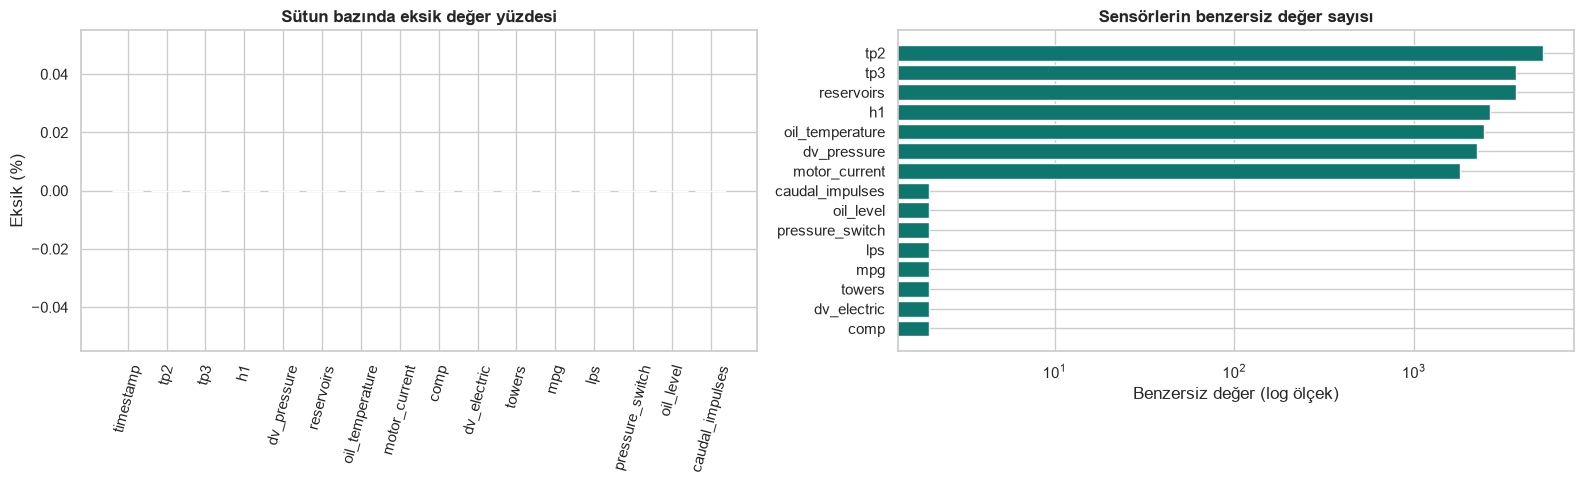

In [7]:
# Eksik yüzdeleri grafik için orijinal sütun sırasına alıyoruz.
missing_pct = (100 * raw.isna().mean()).reindex(raw.columns)

# Birinci panelde eksiklik, ikinci panelde benzersiz değer sayısını gösteriyoruz.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(missing_pct.index, missing_pct.values, color="#2563eb")
axes[0].set_title("Sütun bazında eksik değer yüzdesi")
axes[0].set_ylabel("Eksik (%)")
axes[0].tick_params(axis="x", rotation=75)

unique_counts = raw[all_sensors].nunique().sort_values()
axes[1].barh(unique_counts.index, unique_counts.values, color="#0f766e")
axes[1].set_xscale("log")
axes[1].set_title("Sensörlerin benzersiz değer sayısı")
axes[1].set_xlabel("Benzersiz değer (log ölçek)")

plt.tight_layout()
plt.show()

### A4. Örnekleme ritmi ve günlük kapsama

Kaynak açıklamalarında örnekleme sıklığı farklı şekillerde ifade edilmiştir. Varsaymak yerine
ardışık zaman damgaları arasındaki farkı ölçüyoruz. Medyan tipik ritmi, yüksek yüzdelikler ise
kesinti ve boşlukların büyüklüğünü gösterir.

Günlük satır sayısı grafiği, belirli günlerde cihazın daha az gözlem üretip üretmediğini görünür kılar.

,saniye
count,"1,516,947.0000"
mean,12.1412
std,314.1073
min,8.0000
50%,10.0000
90%,10.0000
95%,10.0000
99%,12.0000
99.9%,13.0000
max,"172,918.0000"


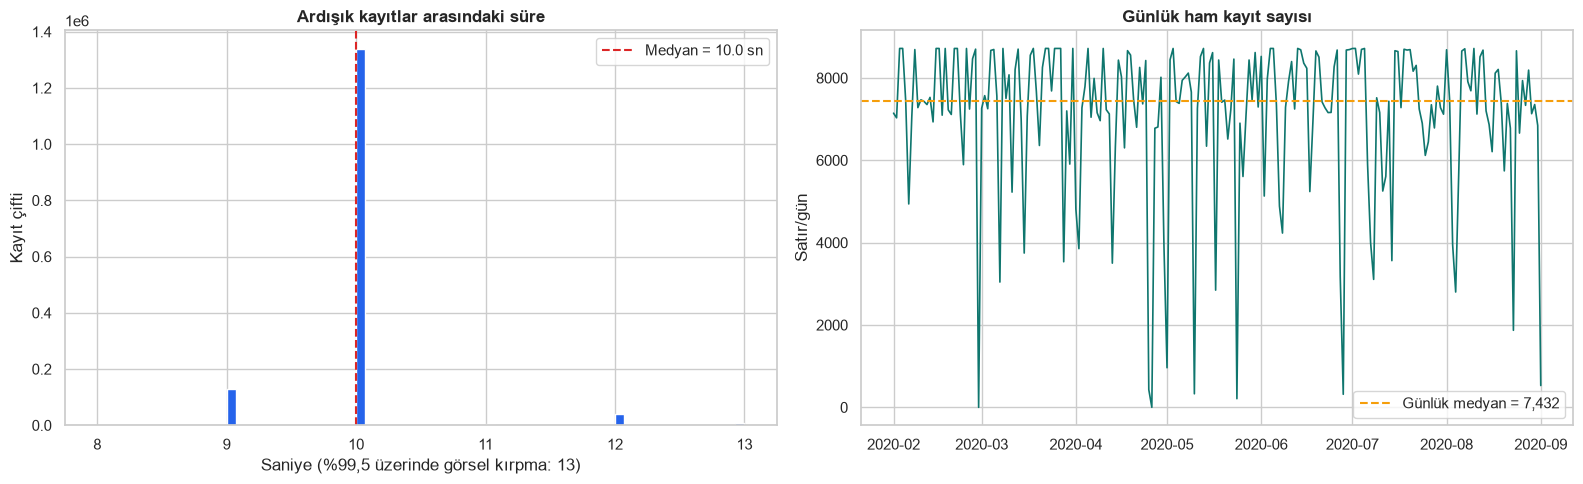

In [8]:
# Ardışık zaman damgaları arasındaki farkı saniye cinsinden hesaplıyoruz.
cadence_seconds_full = raw["timestamp"].diff().dt.total_seconds().dropna()

# Tipik değer ile uzun kuyruğu birlikte görmek için seçili yüzdelikleri istiyoruz.
cadence_summary_full = cadence_seconds_full.describe(
    percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
).to_frame("saniye")
display(cadence_summary_full)

# Gün başına gerçek kayıt sayısını hesaplıyoruz.
daily_row_count = raw.set_index("timestamp").resample("1D").size()

# Histogramı aşırı uzun boşlukların ezmesini önlemek için %99,5'te görsel olarak kırpıyoruz.
cadence_cap = cadence_seconds_full.quantile(0.995)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(cadence_seconds_full.clip(upper=cadence_cap), bins=70, color="#2563eb")
axes[0].axvline(cadence_seconds_full.median(), color="#dc2626", linestyle="--",
                label=f"Medyan = {cadence_seconds_full.median():.1f} sn")
axes[0].set_title("Ardışık kayıtlar arasındaki süre")
axes[0].set_xlabel(f"Saniye (%99,5 üzerinde görsel kırpma: {cadence_cap:.0f})")
axes[0].set_ylabel("Kayıt çifti")
axes[0].legend()

axes[1].plot(daily_row_count.index, daily_row_count.values, color="#0f766e", linewidth=1.2)
axes[1].axhline(daily_row_count.median(), color="#f59e0b", linestyle="--",
                label=f"Günlük medyan = {daily_row_count.median():,.0f}")
axes[1].set_title("Günlük ham kayıt sayısı")
axes[1].set_ylabel("Satır/gün")
axes[1].legend()

plt.tight_layout()
plt.show()

### A5. Analog sensörlerin betimsel istatistikleri

Ortalama ve standart sapma tek başına yeterli değildir; kompresör farklı çalışma rejimlerinde
bulunduğu için dağılımlar çarpık ve çok tepeli olabilir. Bu nedenle medyan, `%1`, `%25`, `%75`,
`%99` yüzdeliklerini birlikte hesaplıyoruz.

Yoğun grafiklerde tam 1,5 milyon noktayı çizmek görüntüyü ağırlaştırır. Sayısal özet tam veriden,
histogramlar sabit seed ile seçilmiş 150 bin satırlık örnekten üretilir.

,adet,ortalama,std,minimum,p01,p25,medyan,p75,p99,maksimum
tp2,"1,516,948.0000",1.3678,3.2578,-0.0320,-0.0240,-0.0140,-0.0120,-0.0100,10.3520,10.6760
tp3,"1,516,948.0000",8.9846,0.6388,0.7300,7.8760,8.4920,8.9600,9.4920,10.1400,10.3020
h1,"1,516,948.0000",7.5682,3.3310,-0.0360,-0.0240,8.2540,8.7840,9.3740,10.1140,10.2880
dv_pressure,"1,516,948.0000",0.0560,0.3796,-0.0320,-0.0260,-0.0220,-0.0200,-0.0180,2.1120,9.8440
reservoirs,"1,516,948.0000",8.9852,0.6380,0.7120,7.8760,8.4940,8.9600,9.4920,10.1380,10.3000
oil_temperature,"1,516,948.0000",62.6442,6.5149,15.4000,48.8250,57.7750,62.7000,67.2500,76.1750,89.0500
motor_current,"1,516,948.0000",2.0502,2.3018,0.0200,0.0350,0.0400,0.0450,3.8075,6.1875,9.2950


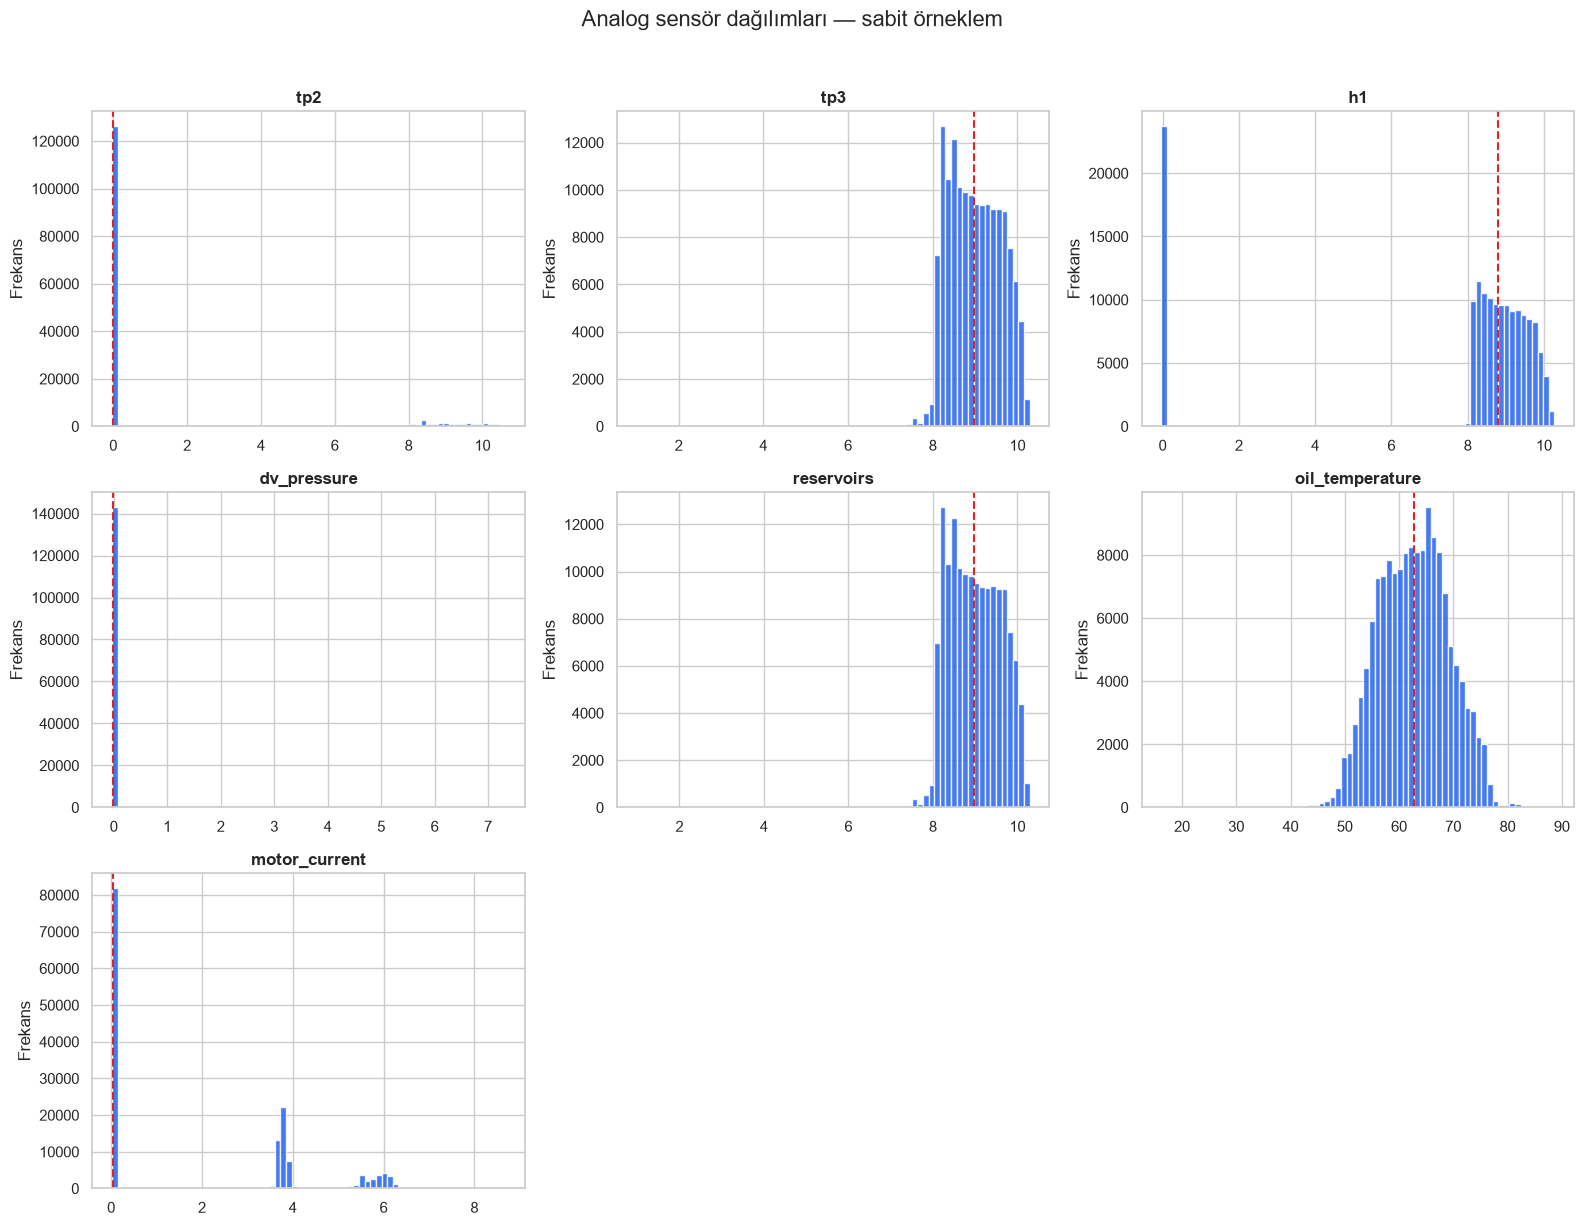

In [9]:
# Tam veri üzerinden dayanıklı ve klasik özet istatistikleri hesaplıyoruz.
analog_summary = raw[analog_sensors].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T

# Sütunları Türkçe başlıklarla daha okunur hale getiriyoruz.
analog_summary = analog_summary.rename(columns={
    "count": "adet", "mean": "ortalama", "std": "std",
    "min": "minimum", "1%": "p01", "25%": "p25",
    "50%": "medyan", "75%": "p75", "99%": "p99", "max": "maksimum",
})
display(analog_summary)

# Yoğun grafikler için yeniden üretilebilir bir alt örnek seçiyoruz.
metro_plot_sample = raw.sample(n=min(150_000, len(raw)), random_state=42)

# Yedi analog sensörü çoklu panel histogramda gösteriyoruz.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for axis, sensor in zip(axes.ravel(), analog_sensors):
    axis.hist(metro_plot_sample[sensor].dropna(), bins=70, color="#2563eb", alpha=0.85)
    axis.axvline(metro_plot_sample[sensor].median(), color="#dc2626", linestyle="--")
    axis.set_title(sensor)
    axis.set_ylabel("Frekans")

# Kullanılmayan iki paneli boş bırakmak yerine kapatıyoruz.
for axis in axes.ravel()[len(analog_sensors):]:
    axis.axis("off")

fig.suptitle("Analog sensör dağılımları — sabit örneklem", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Dağılım yorumu:** Basınç ve motor akımı dağılımlarındaki birden fazla tepe, cihazın kapalı,
yükleniyor, aktif veya tahliye halinde olduğu rejimlerden kaynaklanabilir. IQR dışındaki her değeri
silmek, gerçek çalışma modlarını veri setinden yok edebilir. Zaman serisi sensörlerinde aykırı değer
kararı tek değişkenli kutu grafiğe göre otomatik verilmemelidir.

### A6. Dijital sensörler: aktiflik ve geçiş sayısı

Dijital sinyal için ortalama, pratikte `1` olma oranıdır. Ancak iki sinyalin aktiflik oranı aynı
olsa bile biri gün boyu açık, diğeri sık açılıp kapanıyor olabilir. Bu yüzden aktiflik oranını ve
ardışık satırlardaki durum değişimi sayısını birlikte hesaplıyoruz.

,aktif_yüzde,durum_geçişi
pressure_switch,99.1437,23628
caudal_impulses,93.7107,15292
towers,91.9848,64580
oil_level,90.4156,15336
comp,83.6957,33846
mpg,83.2664,31012
dv_electric,16.0611,31448
lps,0.3420,254


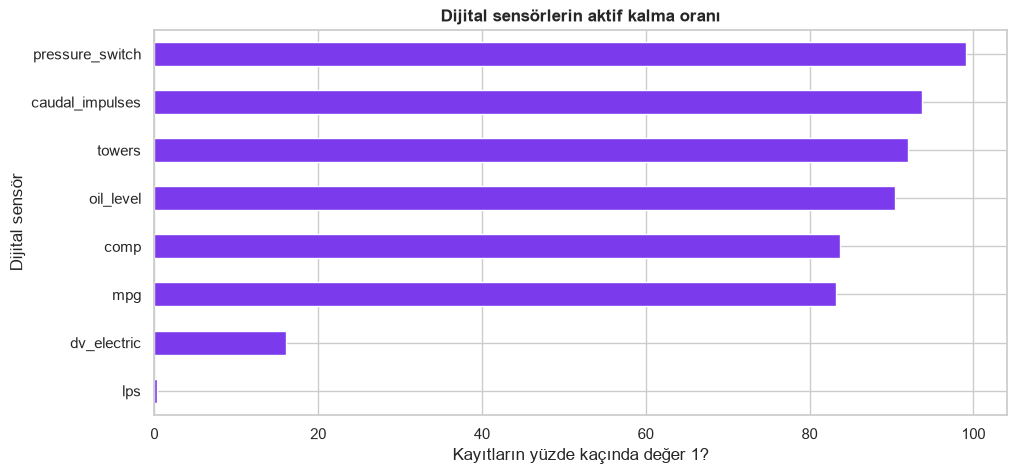

In [10]:
# Dijital sinyallerin 1 olma oranını yüzdeye çeviriyoruz.
active_share = 100 * raw[digital_sensors].mean()

# Bir önceki kayda göre değişen durumları sayıyoruz.
transition_count = raw[digital_sensors].diff().ne(0).sum() - 1

# İki ölçüyü aynı tabloda birleştiriyoruz.
digital_behavior = pd.DataFrame({
    "aktif_yüzde": active_share,
    "durum_geçişi": transition_count.astype(int),
}).sort_values("aktif_yüzde", ascending=False)
display(digital_behavior)

# Aktiflik oranlarını yatay grafikle karşılaştırıyoruz.
ax = digital_behavior.sort_values("aktif_yüzde")["aktif_yüzde"].plot(
    kind="barh", color="#7c3aed"
)
ax.set_title("Dijital sensörlerin aktif kalma oranı")
ax.set_xlabel("Kayıtların yüzde kaçında değer 1?")
ax.set_ylabel("Dijital sensör")
plt.show()

### A7. Analog sensör korelasyonları

Pearson korelasyonu doğrusal birlikte değişimi ölçer. Yüksek korelasyon iki sensörün benzer fiziksel
süreci izlediğini gösterebilir; birinin diğerine neden olduğunu göstermez. Ayrıca milyonlarca ardışık
satır bağımsız değildir, bu nedenle klasik p-değerleri anlamlı bir kanıt gibi kullanılmamalıdır.

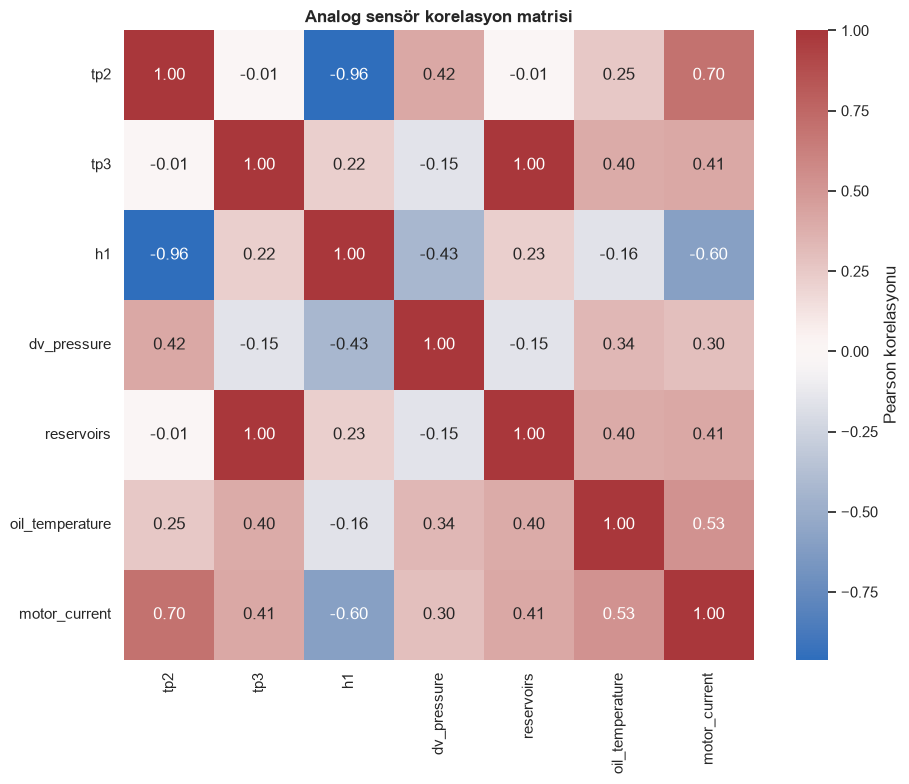

korelasyon  mutlak
tp3             reservoirs           1.0000  1.0000
tp2             h1                  -0.9613  0.9613
                motor_current        0.6975  0.6975
h1              motor_current       -0.6002  0.6002
oil_temperature motor_current        0.5287  0.5287
h1              dv_pressure         -0.4255  0.4255
tp2             dv_pressure          0.4150  0.4150
tp3             motor_current        0.4138  0.4138
reservoirs      motor_current        0.4127  0.4127
                oil_temperature      0.4016  0.4016

In [11]:
# Tam veride analog sensörler arasındaki Pearson korelasyon matrisini hesaplıyoruz.
analog_corr = raw[analog_sensors].corr()

# Simetrik matrisi renkli ısı haritasıyla gösteriyoruz.
plt.figure(figsize=(10, 8))
sns.heatmap(
    analog_corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    cbar_kws={"label": "Pearson korelasyonu"},
)
plt.title("Analog sensör korelasyon matrisi")
plt.tight_layout()
plt.show()

# Mutlak değeri en yüksek benzersiz sensör çiftlerini listeliyoruz.
upper_mask = np.triu(np.ones(analog_corr.shape, dtype=bool), k=1)
strongest_pairs = (
    analog_corr.where(upper_mask)
    .stack()
    .rename("korelasyon")
    .to_frame()
    .assign(mutlak=lambda frame: frame["korelasyon"].abs())
    .sort_values("mutlak", ascending=False)
    .head(10)
)
display(strongest_pairs)

### A8. Kompresör çalışma rejimlerine göre sensör davranışı

`comp` ve `mpg` dijital kontrol sinyalleridir. Analog değerleri bu durumlara göre karşılaştırmak,
histogramlardaki çok tepeli yapının çalışma rejimleriyle ilişkisini anlamaya yardımcı olur.

Burada yapılan karşılaştırma gözlemseldir. Gruplar rastgele deney kolları değildir; nedensel etki
olarak yorumlanmaz.

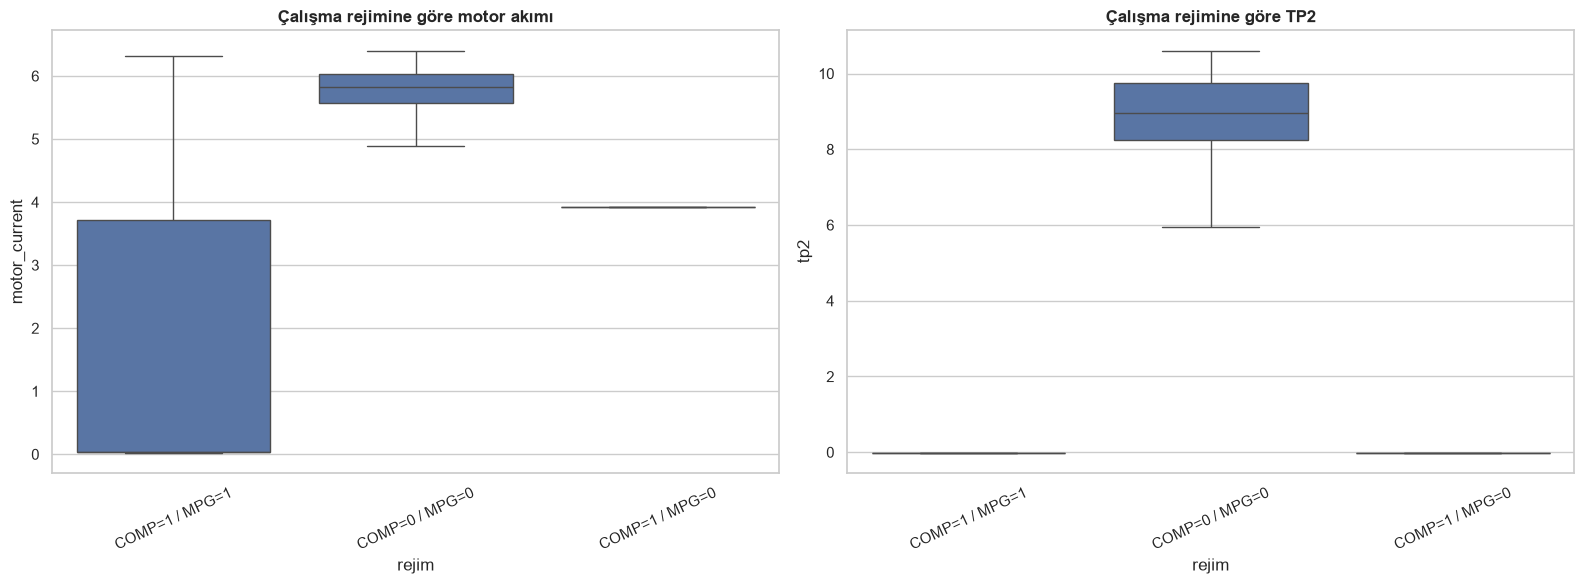

In [12]:
# Yoğun ham veriyi görsel olarak dengeli tutmak için daha küçük sabit örnek kullanıyoruz.
regime_sample = raw.sample(n=min(100_000, len(raw)), random_state=42).copy()

# COMP ve MPG sinyallerini birleşik, okunabilir çalışma rejimi etiketi yapıyoruz.
regime_sample["rejim"] = (
    "COMP=" + regime_sample["comp"].astype("Int64").astype(str)
    + " / MPG=" + regime_sample["mpg"].astype("Int64").astype(str)
)

# Motor akımı ve TP2 basıncını aynı rejimlere göre yan yana kutu grafikle karşılaştırıyoruz.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=regime_sample, x="rejim", y="motor_current", showfliers=False, ax=axes[0])
axes[0].set_title("Çalışma rejimine göre motor akımı")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=regime_sample, x="rejim", y="tp2", showfliers=False, ax=axes[1])
axes[1].set_title("Çalışma rejimine göre TP2")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### A9. Zaman içinde günlük sensör eğilimleri

10 saniyelik ham çizgiyi aylar boyunca çizmek siyah bir bant üretir. Günlük medyan tipik seviyeyi,
`%10–%90` bandı gün içi değişkenliği gösterir. Böylece uzun dönem kayma ve olay çevreleri daha okunur
hale gelir. Toplulaştırma yalnız görselleştirme içindir; model ham kaydı doğrudan kullanmaz.

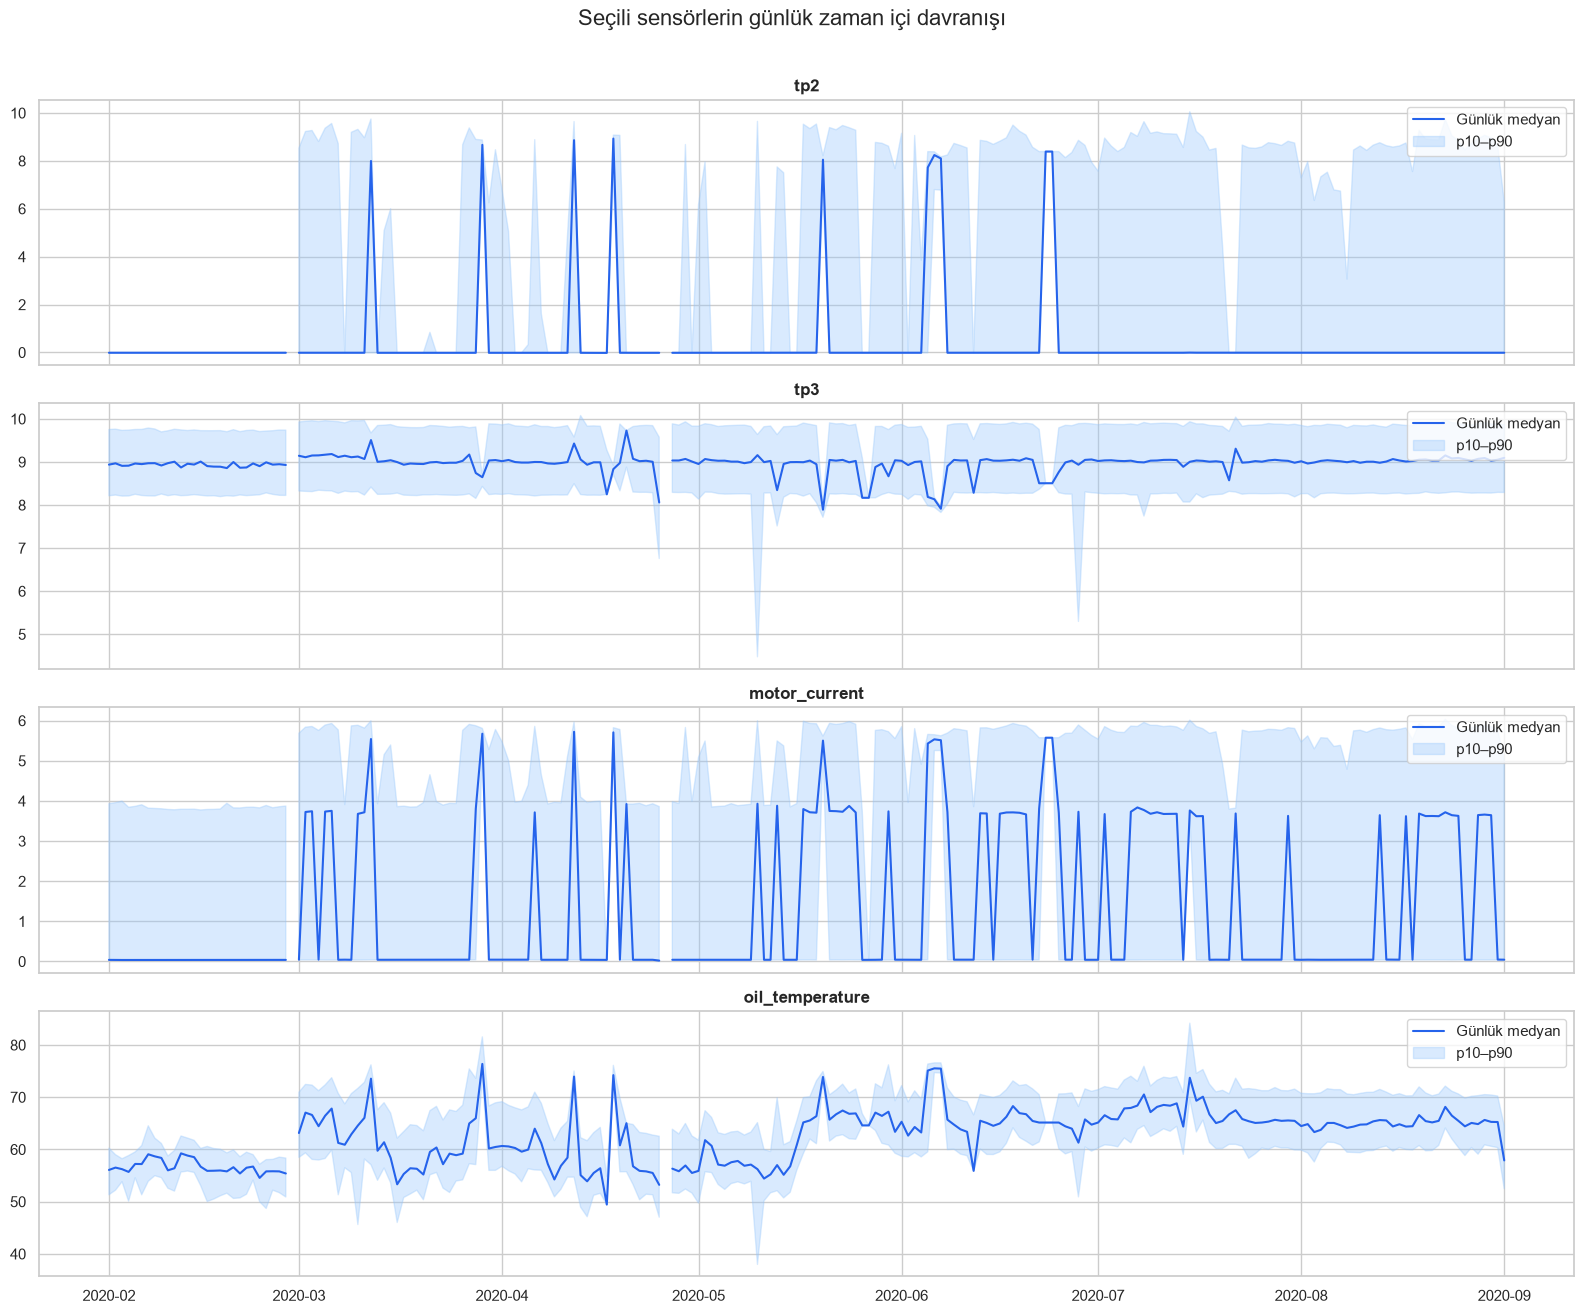

In [13]:
# Zaman damgasını indeks yapıp seçili analog sensörleri günlük özetliyoruz.
daily_analog = raw.set_index("timestamp")[["tp2", "tp3", "motor_current", "oil_temperature"]].resample("1D").agg(
    ["median", lambda values: values.quantile(0.10), lambda values: values.quantile(0.90)]
)

# Lambda isimlerini daha anlaşılır p10/p90 başlıklarına çeviriyoruz.
daily_analog.columns = pd.MultiIndex.from_tuples([
    (sensor, "medyan" if stat == "median" else "p10" if stat == "<lambda_0>" else "p90")
    for sensor, stat in daily_analog.columns
])

# Dört sensörü ayrı eksenlerde çiziyoruz; farklı ölçekleri tek eksende karıştırmıyoruz.
fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
for axis, sensor in zip(axes, ["tp2", "tp3", "motor_current", "oil_temperature"]):
    axis.plot(daily_analog.index, daily_analog[(sensor, "medyan")], color="#2563eb", label="Günlük medyan")
    axis.fill_between(
        daily_analog.index,
        daily_analog[(sensor, "p10")],
        daily_analog[(sensor, "p90")],
        color="#93c5fd",
        alpha=0.35,
        label="p10–p90",
    )
    axis.set_title(sensor)
    axis.legend(loc="upper right")

fig.suptitle("Seçili sensörlerin günlük zaman içi davranışı", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### A10. Resmî hava kaçağı olaylarının çevresinde sensör görünümü

Dört olay için başlangıçtan 48 saat önce ile olay sonundan 12 saat sonrasını gösteriyoruz. Ham
10 saniyelik veri yerine saatlik medyan kullanmak genel desenin okunmasını sağlar.

Olay çevresinde değişim görmek, o sensörün kök neden olduğu anlamına gelmez. Olaylar aynı arıza
ailesinden gelir ve bağımsız büyük örneklem oluşturmaz.

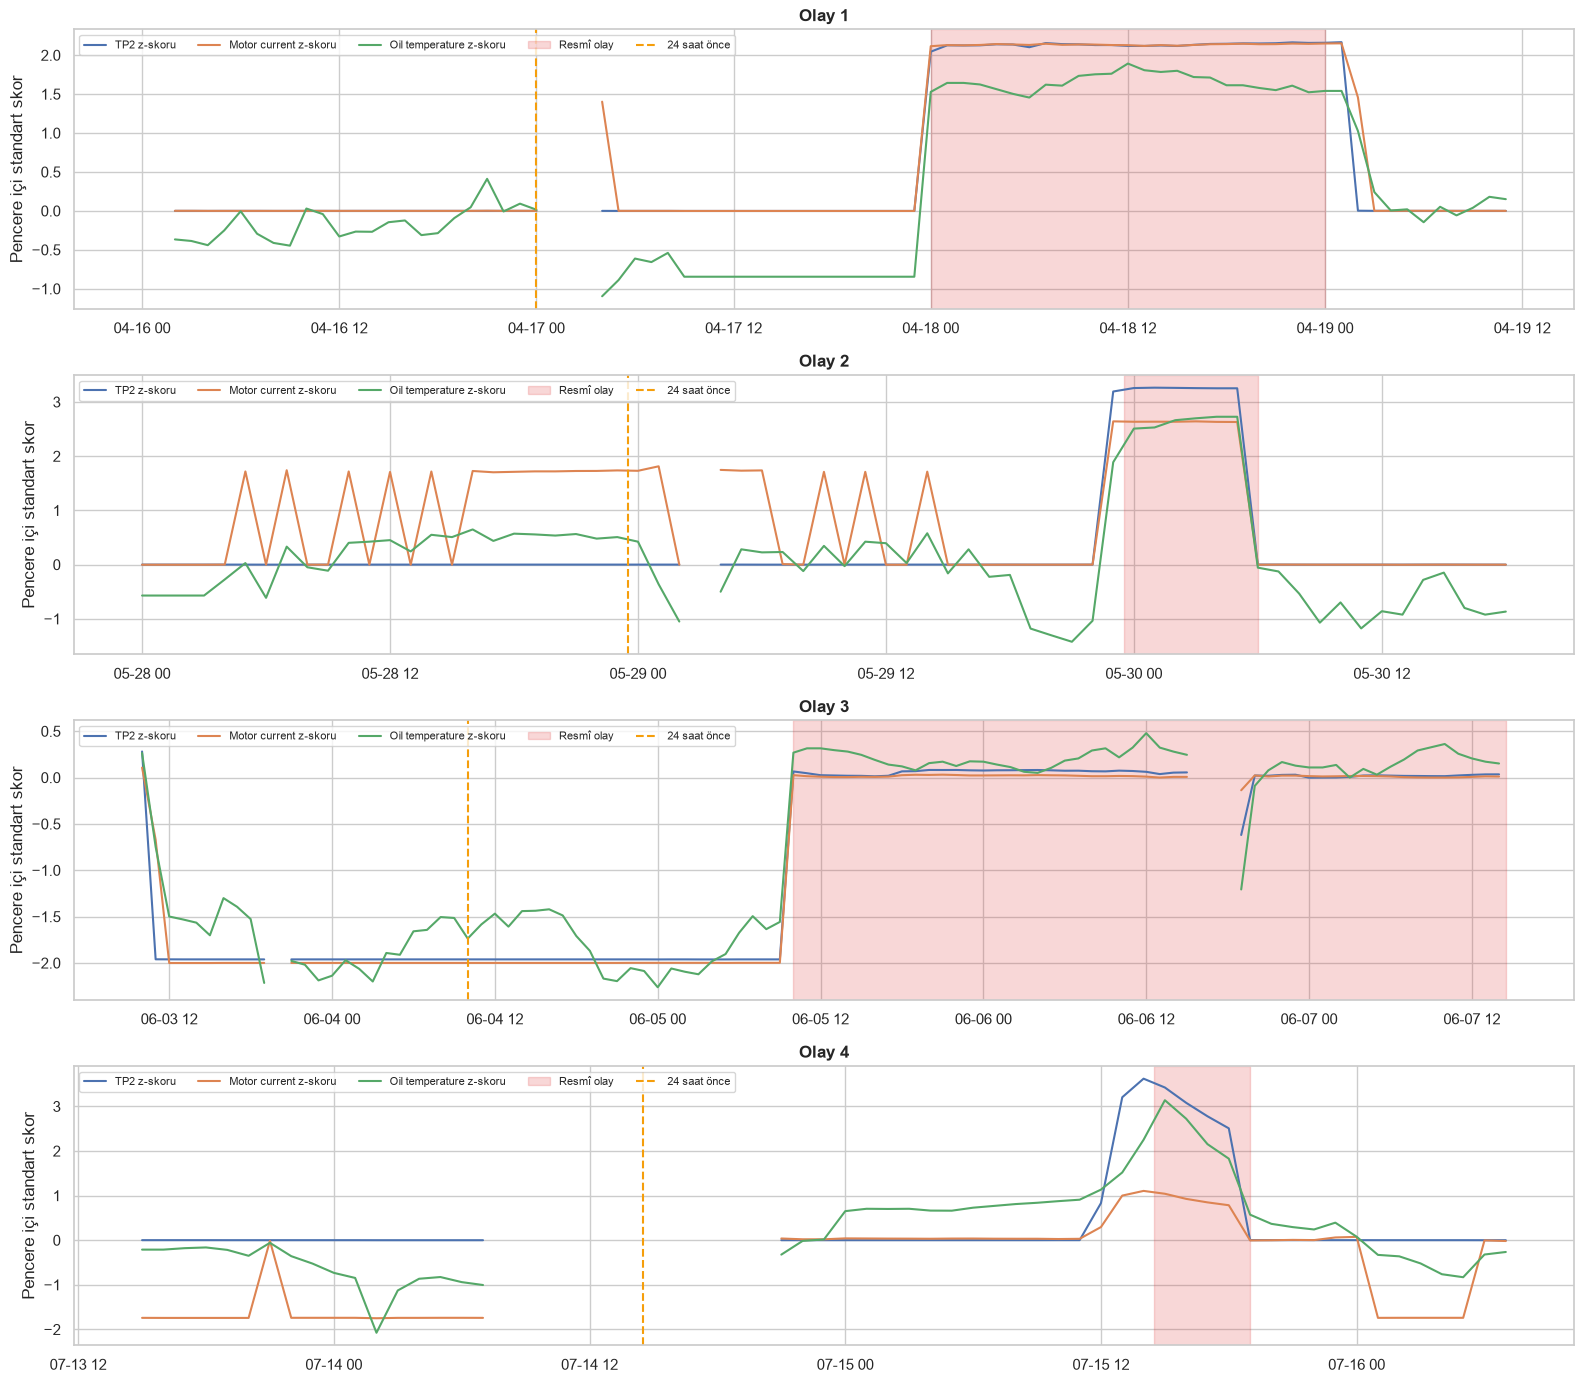

In [14]:
# UCI veri kartındaki dört konsolide olayın tarihlerini tanımlıyoruz.
official_events = pd.DataFrame({
    "event_id": ["Olay 1", "Olay 2", "Olay 3", "Olay 4"],
    "start": pd.to_datetime([
        "2020-04-18 00:00", "2020-05-29 23:30",
        "2020-06-05 10:00", "2020-07-15 14:30",
    ]),
    "end": pd.to_datetime([
        "2020-04-18 23:59", "2020-05-30 06:00",
        "2020-06-07 14:30", "2020-07-15 19:00",
    ]),
})

# Olay çevresi için saatlik medyan sensör tablosu oluşturuyoruz.
hourly_event_signals = raw.set_index("timestamp")[["tp2", "motor_current", "oil_temperature"]].resample("1h").median()

# Her olayı ayrı satırda çizerek ölçek ve zaman ilişkisini koruyoruz.
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharey=False)
for axis, event in zip(axes, official_events.itertuples(index=False)):
    window = hourly_event_signals.loc[
        event.start - pd.Timedelta(hours=48): event.end + pd.Timedelta(hours=12)
    ]
    normalized = (window - window.median()) / window.std(ddof=0).replace(0, np.nan)
    axis.plot(normalized.index, normalized["tp2"], label="TP2 z-skoru")
    axis.plot(normalized.index, normalized["motor_current"], label="Motor current z-skoru")
    axis.plot(normalized.index, normalized["oil_temperature"], label="Oil temperature z-skoru")
    axis.axvspan(event.start, event.end, color="#dc2626", alpha=0.18, label="Resmî olay")
    axis.axvline(event.start - pd.Timedelta(hours=24), color="#f59e0b", linestyle="--", label="24 saat önce")
    axis.set_title(event.event_id)
    axis.set_ylabel("Pencere içi standart skor")
    axis.legend(ncol=5, fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

### A11. Ham veriden 5 dakikalık özellik tablosuna geçiş

Model 10 saniyelik satırları doğrudan kullanmaz. Analog sinyaller için her 5 dakikada
`mean/std/min/max/last`; dijital sinyaller için `active_ratio/transitions/last` üretilir.
`coverage_ratio`, o kutuda beklenen 30 kaydın ne kadarının geldiğini ölçer.

Bu dönüşüm hem gürültüyü azaltır hem de son 60 dakikayı 12 ardışık kutu olarak temsil etmeyi sağlar.
Merkezli pencere veya gelecekten doldurma kullanılmaz.

,değer
5 dakikalık kutu,"61,393"
Model özelliği,63
Başlangıç,2020-02-01 00:00:00
Bitiş,2020-09-01 04:00:00
%80 altı kapsama kutusu,11092
%80 altı kapsama oranı,18.0672


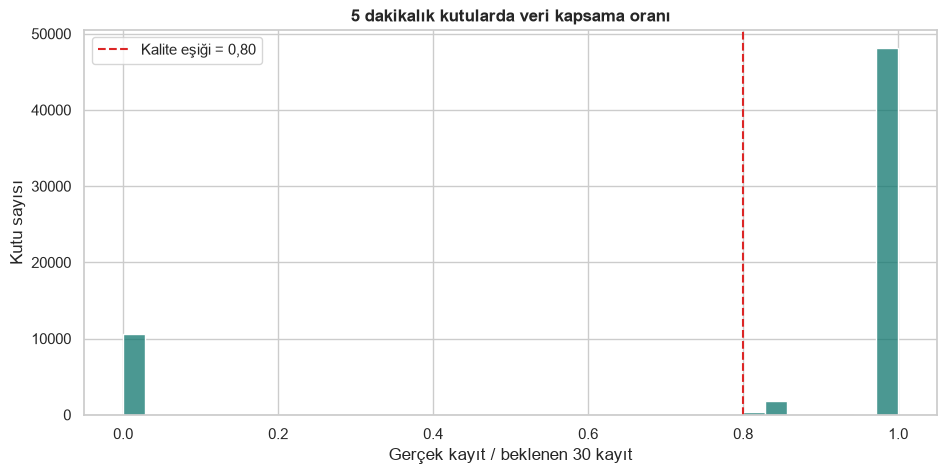

,örnek_özellik_adı
0,tp2__mean
1,tp2__std
2,tp2__min
3,tp2__max
4,tp2__last
5,tp3__mean
6,tp3__std
7,tp3__min
8,tp3__max
9,tp3__last


In [15]:
# Pipeline tarafından üretilmiş tam 5 dakikalık özellik tablosunu okuyoruz.
feature_path = ROOT / "data/processed/features.parquet"
full_features = pd.read_parquet(feature_path)

# İndeks zaman bilgisini özet tabloya dahil ediyoruz.
feature_overview = pd.DataFrame({
    "değer": [
        f"{len(full_features):,}",
        len(full_features.columns) - 1,
        full_features.index.min(),
        full_features.index.max(),
        int(full_features["coverage_ratio"].lt(0.80).sum()),
        100 * full_features["coverage_ratio"].lt(0.80).mean(),
    ]
}, index=[
    "5 dakikalık kutu", "Model özelliği", "Başlangıç", "Bitiş",
    "%80 altı kapsama kutusu", "%80 altı kapsama oranı",
])
display(feature_overview)

# Kapsama oranının dağılımını çiziyoruz.
sns.histplot(full_features["coverage_ratio"], bins=35, color="#0f766e")
plt.axvline(0.80, color="#dc2626", linestyle="--", label="Kalite eşiği = 0,80")
plt.title("5 dakikalık kutularda veri kapsama oranı")
plt.xlabel("Gerçek kayıt / beklenen 30 kayıt")
plt.ylabel("Kutu sayısı")
plt.legend()
plt.show()

# Özellik adlarının ilk bölümünü göstererek dönüşüm şemasını somutlaştırıyoruz.
display(pd.Series(full_features.columns[:35], name="örnek_özellik_adı").to_frame())

### Tam MetroPT-3 EDA özeti

- Veri tek APU’dan gelen 7 analog ve 8 dijital sinyali içerir.
- Satır sayısı büyük olsa da kayıtlar yaklaşık 10 saniye aralıklı ve güçlü otokorelasyonludur.
- Eksik hücre denetimine ek olarak zaman boşlukları ve 5 dakikalık kapsama mutlaka izlenmelidir.
- Analog dağılımlardaki çok tepeli yapı çalışma rejimleriyle ilişkilidir; otomatik aykırı değer silme
  gerçek fiziksel davranışı kaldırabilir.
- Sensör korelasyonu ve olay çevresi değişimleri mekanik nedensellik kanıtı değildir.
- Modelleme, tam ham akışı nedensel 5 dakikalık özetlere ve geçmiş 60 dakikalık dizilere dönüştürür.

Bundan sonraki bölüm, bu veri yapısı üzerinde kilitlenmiş deney tasarımını ve model sonuçlarını inceler.

## 4. Deney sözleşmesi: veri bölünmesi ve leakage kontrolü

Zaman serisinde rastgele train/test bölmek gelecek bilgiyi geçmişe taşıyabilir. MetroGuard şu
kronolojik sözleşmeyi kilitler:

- **1–21 Şubat:** model/temsil öğrenimi,
- **22–29 Şubat:** skor normalizasyonu ve alarm eşiği kalibrasyonu,
- **Mart–Eylül:** yalnızca bir kez kullanılan test dönemi.

Aşağıdaki hücre sayıların gerçekten makine üretimi `metrics.json` dosyasından geldiğini gösterir.

,pencere_sayısı
train_windows,5033
calibration_windows,1739
test_windows,40763


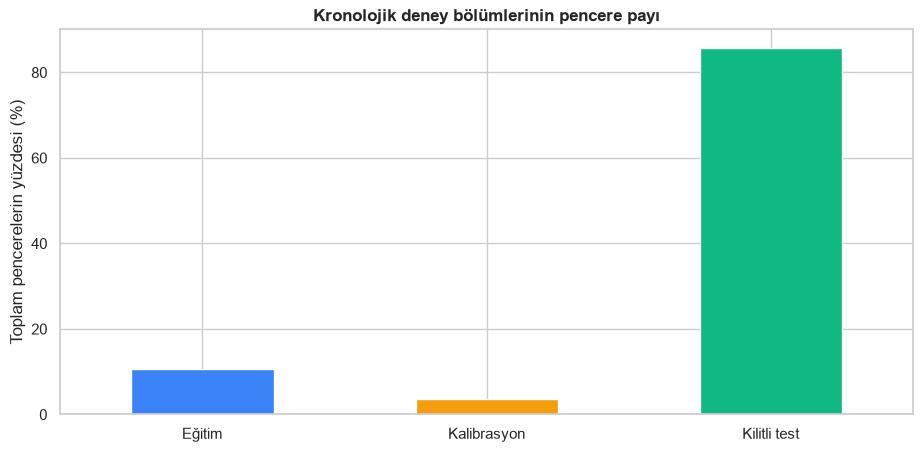

In [16]:
# JSON dosyasını UTF-8 olarak açıyoruz; Türkçe karakter ve platform farklarını güvenli tutuyoruz.
with files["metrics"].open("r", encoding="utf-8") as handle:
    metrics_payload = json.load(handle)

# Yalnızca bölünme sayılarını ayrı bir Series'e alarak okunabilir hale getiriyoruz.
split_counts = pd.Series(metrics_payload["splits"], name="pencere_sayısı")

# Eğitim, kalibrasyon ve test pencere sayılarını tablo olarak gösteriyoruz.
display(split_counts.to_frame())

# Oransal büyüklükleri hesaplamak, test döneminin deneydeki ağırlığını görmemizi sağlar.
split_share = 100 * split_counts / split_counts.sum()

# Aynı bilgiyi görsel olarak sunuyoruz; bu bir performans grafiği değil, deney tasarımı grafiğidir.
ax = split_share.rename(index={
    "train_windows": "Eğitim",
    "calibration_windows": "Kalibrasyon",
    "test_windows": "Kilitli test",
}).plot(kind="bar", color=["#3b82f6", "#f59e0b", "#10b981"])
ax.set_title("Kronolojik deney bölümlerinin pencere payı")
ax.set_ylabel("Toplam pencerelerin yüzdesi (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()

**İstatistiksel yorum:** Test pencerelerinin sayıca büyük olması dört bağımsız olay olduğu
anlamına gelmez. Ardışık 5 dakikalık pencereler yüksek otokorelasyon taşır. Bu nedenle
`40.763` satırı `40.763 bağımsız kanıt` gibi okunamaz; olay-temelli ana metrik hâlâ `k/4`’tür.

## 5. Model karşılaştırma tablosunu üretme

Tek bir “accuracy” sayısı bu problem için uygun değildir. Her model için birlikte okuyacağımız
sütunlar:

- **Erken olay yakalama:** 24–2 saat önce alarm verilen olay sayısı,
- **Yanlış alarm/gün:** normal maruziyet başına operasyonel yük,
- **PR-AUC:** dengesiz olay aralıklarında pozitif sınıfa odaklı sıralama kalitesi,
- **Alarm süresi:** test zamanının ne kadarında sistemin alarmda kaldığı,
- **Lead time:** başarılı erken yakalamalarda ne kadar önce uyarı verildiği.

In [17]:
# JSON içindeki model sözlüğünü satır tablosuna dönüştürüyoruz.
model_table = pd.DataFrame(metrics_payload["models"]).T.reset_index(names="model")

# Uzun makine sütun adlarını Türkçe ve okunabilir başlıklara çeviriyoruz.
model_table = model_table.rename(columns={
    "early_event_recall": "erken_recall",
    "false_alarms_per_day": "yanlış_alarm_gün",
    "lead_time_median_hours": "medyan_lead_saat",
    "alarm_precision": "alarm_precision",
    "time_in_alert_percent": "alarm_süresi_yüzde",
    "pr_auc_official_failure_intervals": "pr_auc",
    "roc_auc_official_failure_intervals": "roc_auc",
})

# Analizde kullanacağımız çekirdek sütunları belirli bir sırayla seçiyoruz.
comparison_columns = [
    "model", "erken_recall", "yanlış_alarm_gün", "medyan_lead_saat",
    "alarm_precision", "alarm_süresi_yüzde", "pr_auc", "roc_auc"
]

# Birincil modelin adını ayrıca saklıyoruz; test sonucuna bakıp sonradan model değiştirmiyoruz.
primary_model = metrics_payload["primary_model"]

# Tabloyu yanlış alarm oranına göre sıralamak yalnızca okunabilirlik içindir; model seçimi değildir.
display(model_table[comparison_columns].sort_values("yanlış_alarm_gün"))

print(f"Önceden belirlenmiş birincil model: {primary_model}")

,model,erken_recall,yanlış_alarm_gün,medyan_lead_saat,alarm_precision,alarm_süresi_yüzde,pr_auc,roc_auc
1,pca,1/4,0.6012,13.2500,0.0536,8.8929,0.2586,0.9647
2,isolation_forest,4/4,0.8111,24.0000,0.0403,35.3630,0.4847,0.9832
3,tcn_autoencoder,3/4,1.2592,15.5833,0.0306,18.1537,0.2419,0.9618
0,robust_z,4/4,1.4350,11.2083,0.0232,14.7487,0.1342,0.9281


Önceden belirlenmiş birincil model: tcn_autoencoder


### Neden ROC-AUC yerine PR-AUC’yi öne çıkarıyoruz?

Resmî arıza aralıkları test zamanının küçük bir kısmını kaplar. Böyle dengesiz bir veri setinde
çok sayıdaki doğru negatif ROC-AUC’yi yüksek gösterebilir. PR-AUC ise alarm verilen noktaların
pozitif olay aralıklarıyla ne ölçüde örtüştüğüne daha duyarlıdır.

Örneğin PCA’nın ROC-AUC’si yüksek görünürken yalnız `1/4` olayı erken yakalaması, tek bir sıralama
metriğinin operasyonel hedefi açıklamaya yetmediğini gösterir.

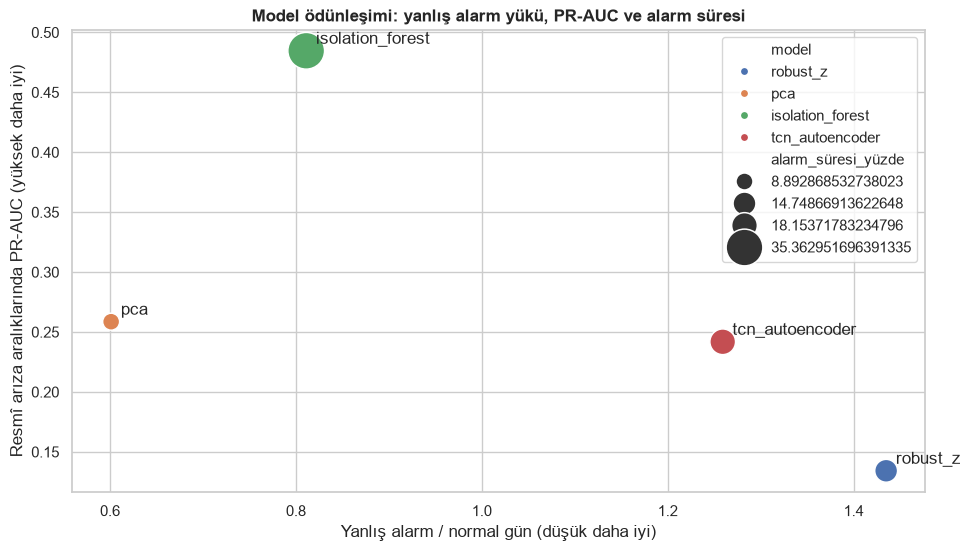

In [18]:
# Operasyonel ödünleşimi iki eksende gösteriyoruz: sola gitmek daha az yanlış alarm demektir.
fig, ax = plt.subplots(figsize=(11, 6))

# Nokta büyüklüğünü alarmda kalınan süreyle ölçekliyoruz; büyük nokta daha fazla alarm bütçesidir.
sns.scatterplot(
    data=model_table,
    x="yanlış_alarm_gün",
    y="pr_auc",
    size="alarm_süresi_yüzde",
    hue="model",
    sizes=(150, 700),
    ax=ax,
)

# Her noktanın yanına model adını yazarak lejant dışında da okunabilirlik sağlıyoruz.
for _, row in model_table.iterrows():
    ax.annotate(row["model"], (row["yanlış_alarm_gün"], row["pr_auc"]),
                xytext=(7, 5), textcoords="offset points")

ax.set_title("Model ödünleşimi: yanlış alarm yükü, PR-AUC ve alarm süresi")
ax.set_xlabel("Yanlış alarm / normal gün (düşük daha iyi)")
ax.set_ylabel("Resmî arıza aralıklarında PR-AUC (yüksek daha iyi)")
plt.show()

**Yorum:** Isolation Forest, yüksek PR-AUC ve dört erken olay ile güçlü görünür; ancak test
süresinin yaklaşık `%35,36`’sında alarmda kalır. TCN daha düşük PR-AUC ve `3/4` erken yakalama
üretse de önceden belirlenmiş birincil modeldir. Test sonucuna bakıp Isolation Forest’ı sonradan
“kazanan” ilan etmek post-hoc seçim yanlılığı yaratır.

## 6. Projenin kilitli model karşılaştırma görseli

Aşağıdaki PNG proje pipeline’ı tarafından üretilmiştir. Yeniden çizmek yerine orijinal artefaktı
göstermemizin nedeni, portföy sayfası ile notebook’un aynı kanıtı kullandığını doğrulamaktır.

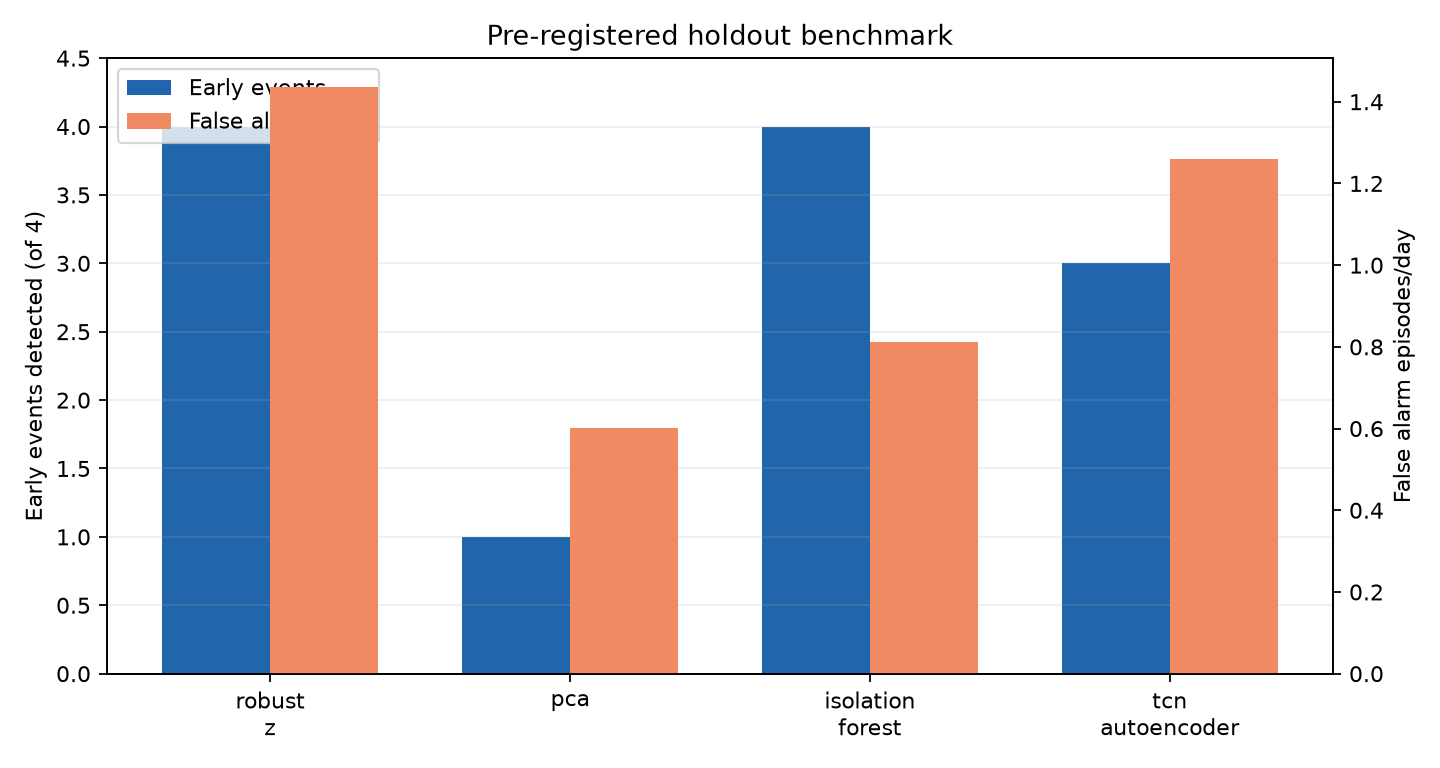

In [19]:
# Orijinal model karşılaştırma görselinin yolunu kuruyoruz.
model_comparison_png = ROOT / "reports/figures/model_comparison.png"

# Görseli notebook çıktısına gömüyoruz; width yalnız ekrandaki sunum boyutunu değiştirir.
display(Image(filename=str(model_comparison_png), width=1100))

## 7. Dashboard görseli: operasyonel sunum katmanı

Dashboard ekranı istatistik üretmez; daha önce hesaplanmış skorları karar vericiye sunar.
Analiz katmanı ile sunum katmanını ayırmak önemlidir: güzel bir gösterge paneli, zayıf validasyonu
güçlendirmez. Bu görsel projedeki tüm PNG varlıklarını kapsamak için notebook’a eklenmiştir.

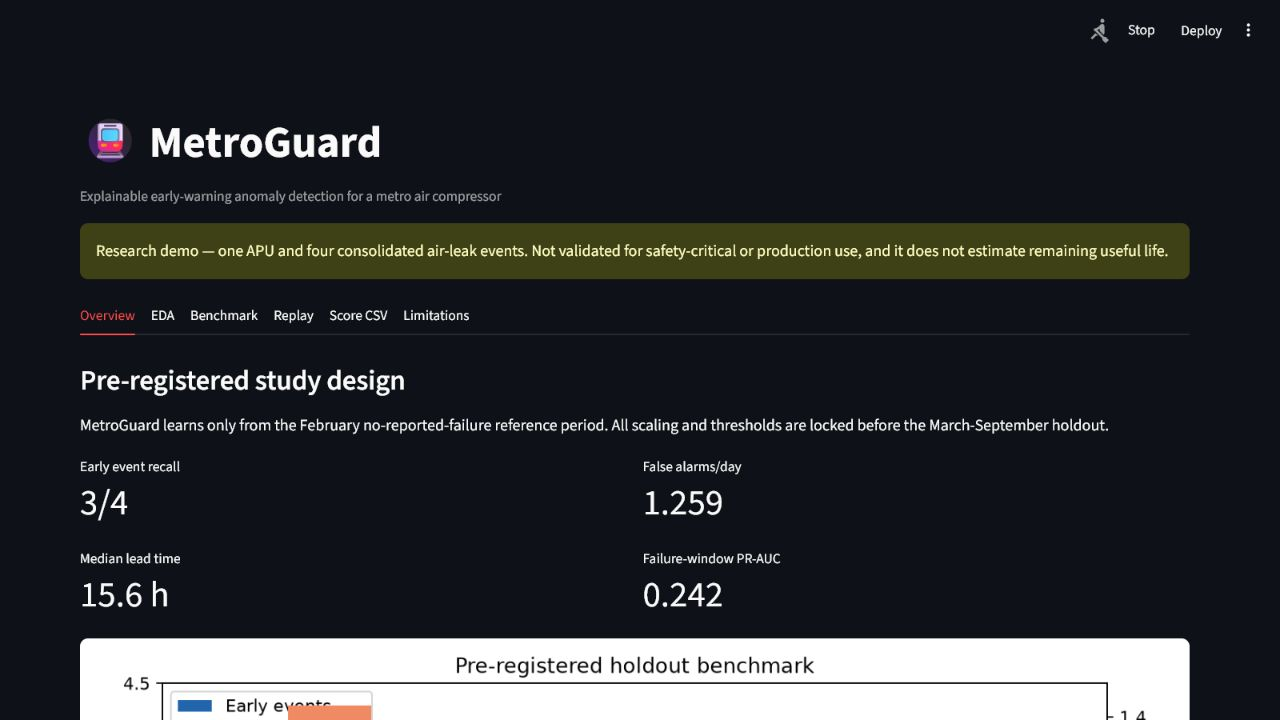

In [20]:
# README'de kullanılan dashboard ekran görüntüsünü açıyoruz.
dashboard_png = ROOT / "docs/dashboard.png"

# Ekran görüntüsünü tam çözünürlüğüne yakın bir genişlikte gösteriyoruz.
display(Image(filename=str(dashboard_png), width=1100))

## 8. Olay bazlı değerlendirme

Satır bazlı metriklerden sonra her resmî olayın ayrı ayrı görülmesi gerekir. Olay tablosunda
`early_detected`, `late_detected` ve `lead_time_hours` sütunları bulunur. Bu ayrım, olay sırasında
verilen alarmı “erken uyarı başarısı” diye saymamızı engeller.

In [21]:
# Olay sonuçlarını CSV dosyasından okuyoruz.
event_results = pd.read_csv(files["events"], parse_dates=["start", "end"])

# Her model için olay durumunu anlaşılır tek bir etikete çeviriyoruz.
event_results["durum"] = np.select(
    [event_results["early_detected"], event_results["late_detected"]],
    ["Erken", "Geç"],
    default="Kaçırıldı",
)

# Model x olay görünümü oluşturmak için pivot tablo kuruyoruz.
event_matrix = event_results.pivot(index="model", columns="event_id", values="durum")

# Dört olayın her modelde nasıl sonuçlandığını gösteriyoruz.
display(event_matrix)

event_id,event_1,event_2,event_3,event_4
model,,,,
isolation_forest,Erken,Erken,Erken,Erken
pca,Geç,Geç,Geç,Erken
robust_z,Erken,Erken,Erken,Erken
tcn_autoencoder,Geç,Erken,Erken,Erken


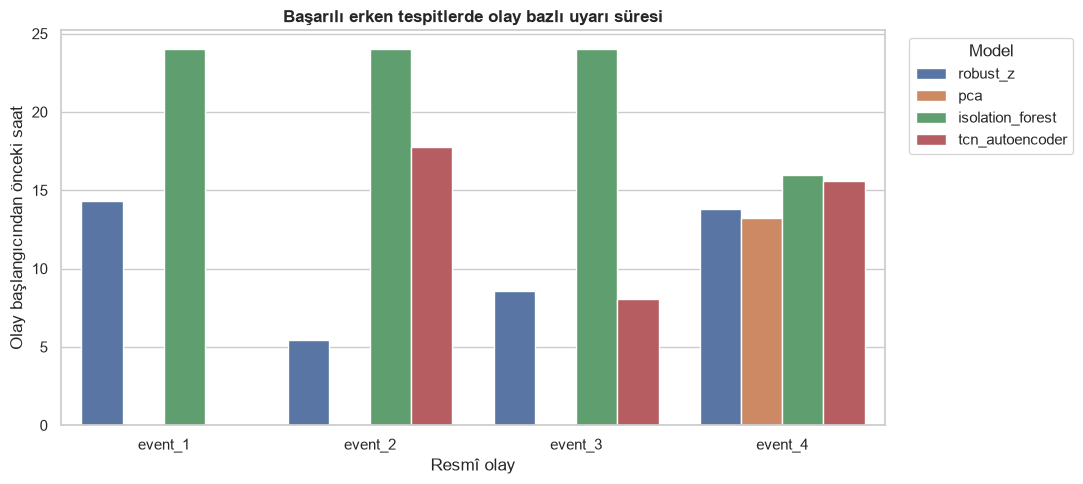

In [22]:
# Başarılı erken tespitleri seçiyoruz; geç veya kaçırılmış olayların lead time'ı erkenlik değildir.
early_only = event_results.loc[event_results["early_detected"]].copy()

# Olay ve model bazında lead time'ı yan yana göstermek için çubuk grafik çiziyoruz.
ax = sns.barplot(data=early_only, x="event_id", y="lead_time_hours", hue="model")
ax.set_title("Başarılı erken tespitlerde olay bazlı uyarı süresi")
ax.set_xlabel("Resmî olay")
ax.set_ylabel("Olay başlangıcından önceki saat")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Yorumlama sınırı:** Medyan lead time yalnız erken yakalanan olaylar üzerinde hesaplanır. TCN için
medyan `15,6 saat`, dört olayın tümündeki ortalama erkenlik değildir; erken yakalanan üç olayın
ortancasıdır. Bu küçük örneklemde güven aralığı vermek aşırı kesinlik izlenimi yaratabilir.

## 9. Yanlış alarm yükü ve alarm precision

Bir bakım ekibi açısından iki farklı soru vardır:

- Günde kaç gereksiz alarm epizodu oluşuyor?
- Alarm verildiğinde bunun resmî olayla örtüşme oranı nedir?

`alarm_precision` düşük olduğunda “model hiçbir şey öğrenmedi” sonucu doğrudan çıkmaz; olayların
çok seyrek olması precision’ı doğal olarak baskılar. Ancak operasyonel iş yükü yine gerçektir.

In [23]:
# Yüzde cinsinden daha sezgisel okumak için precision değerini 100 ile çarpıyoruz.
burden = model_table[["model", "yanlış_alarm_gün", "alarm_precision", "alarm_süresi_yüzde"]].copy()
burden["alarm_precision_yüzde"] = 100 * burden["alarm_precision"].astype(float)

# Ham oran sütununu kaldırıp yorumlanabilir yüzde sütununu tutuyoruz.
burden = burden.drop(columns="alarm_precision")

# En düşük yanlış alarm yükünden başlayarak tabloyu gösteriyoruz.
display(burden.sort_values("yanlış_alarm_gün"))

,model,yanlış_alarm_gün,alarm_süresi_yüzde,alarm_precision_yüzde
1,pca,0.6012,8.8929,5.3571
2,isolation_forest,0.8111,35.3630,4.0268
3,tcn_autoencoder,1.2592,18.1537,3.0568
0,robust_z,1.4350,14.7487,2.3166


## 10. Erken uyarı ufku duyarlılığı

“Erken” tanımı 6, 12, 24 veya 48 saat seçildiğinde sonuç değişebilir. Bu bir hiperparametre
ayarlama fırsatı değil, sonuçların tanıma ne kadar duyarlı olduğunu görme analizidir. Ana sonuç
önceden belirlenmiş 24–2 saat penceresine dayanır.

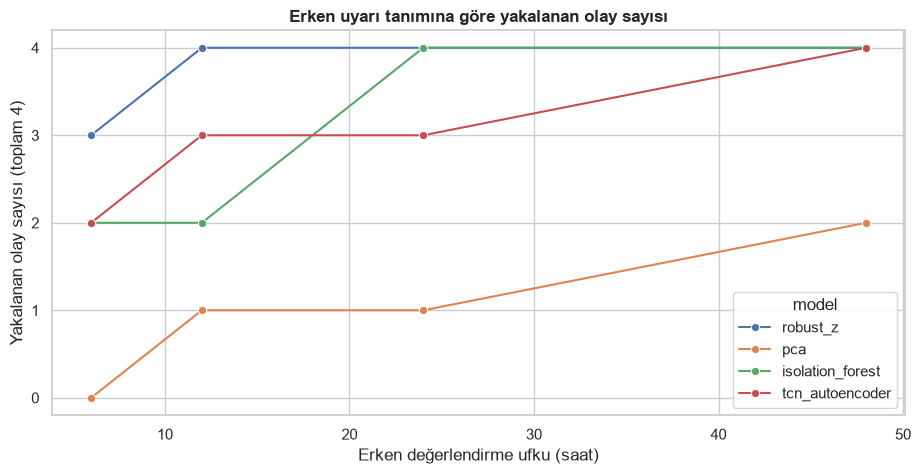

,model,horizon_hours,early_event_recall,false_alarms_per_day,lead_time_median_hours,yakalanan_olay
0,robust_z,6,3/4,1.4165,6.0000,3
1,robust_z,12,4/4,1.4189,10.2917,4
2,robust_z,24,4/4,1.4350,11.2083,4
3,robust_z,48,4/4,1.4335,42.2083,4
4,pca,6,0/4,0.5967,NaN,0
5,pca,12,1/4,0.5945,12.0000,1
6,pca,24,1/4,0.6012,13.2500,1
7,pca,48,2/4,0.5978,40.0833,2
8,isolation_forest,6,2/4,0.8142,6.0000,2
9,isolation_forest,12,2/4,0.8188,12.0000,2


In [24]:
# Farklı erken-uyarı ufuklarında üretilmiş duyarlılık tablosunu okuyoruz.
horizon = pd.read_csv(files["horizon"])

# '3/4' gibi metni grafikte kullanabilmek için pay kısmını sayıya çeviriyoruz.
horizon["yakalanan_olay"] = horizon["early_event_recall"].str.split("/").str[0].astype(int)

# Her modelin ufuk değiştikçe yakaladığı olay sayısını çiziyoruz.
ax = sns.lineplot(
    data=horizon,
    x="horizon_hours",
    y="yakalanan_olay",
    hue="model",
    marker="o",
)
ax.set_title("Erken uyarı tanımına göre yakalanan olay sayısı")
ax.set_xlabel("Erken değerlendirme ufku (saat)")
ax.set_ylabel("Yakalanan olay sayısı (toplam 4)")
ax.set_yticks(range(0, 5))
plt.show()

# Sayısal ayrıntıyı da kaybetmemek için tabloyu gösteriyoruz.
display(horizon)

## 11. TCN öğrenme eğrileri

Eğitim kaybı modelin gördüğü eğitim pencerelerindeki reconstruction hatasıdır. Kalibrasyon kaybı
erken durdurma için kullanılır. İki eğrinin birlikte düşmesi optimizasyonun ilerlediğini gösterir;
test başarısını garanti etmez.

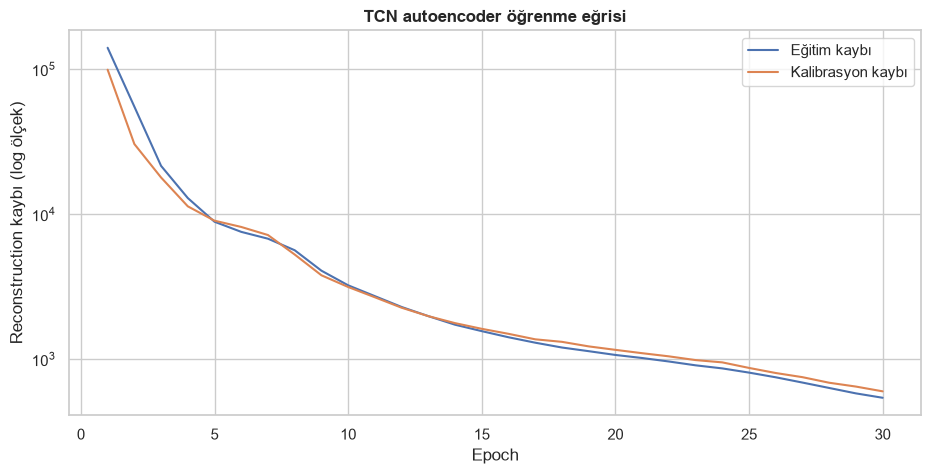

Kilitli en iyi epoch: 30


In [25]:
# JSON içinden epoch bazlı eğitim ve kalibrasyon kayıplarını alıyoruz.
train_loss = np.asarray(metrics_payload["training"]["tcn"]["train_loss"], dtype=float)
calibration_loss = np.asarray(metrics_payload["training"]["tcn"]["calibration_loss"], dtype=float)

# Epoch numaralarını 1'den başlatıyoruz; kullanıcıya 0 tabanlı indeks göstermiyoruz.
epochs = np.arange(1, len(train_loss) + 1)

# Büyük ilk değerler nedeniyle değişimi daha okunur kılmak için y eksenini log ölçeğe alıyoruz.
plt.plot(epochs, train_loss, label="Eğitim kaybı")
plt.plot(epochs, calibration_loss, label="Kalibrasyon kaybı")
plt.yscale("log")
plt.title("TCN autoencoder öğrenme eğrisi")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction kaybı (log ölçek)")
plt.legend()
plt.show()

print(f"Kilitli en iyi epoch: {metrics_payload['training']['tcn']['best_epoch']}")

## 12. Holdout skorları ve alarm epizotları

Ham skor tek başına alarm değildir. Pipeline sırasıyla skoru normalize eder, nedensel EWMA ile
yumuşatır, eşiği aşma durumunu hesaplar ve 3-of-4 persistence uygular. Aşağıdaki kod `alert=True`
serilerinden epizot başlangıçlarını sayarak metrik dosyasıyla tutarlılık kontrolü yapar.

In [26]:
# 40 bin satırlık kilitli test skorlarını Parquet'ten okuyoruz.
scores = pd.read_parquet(files["scores"])

# Zaman sütununu güvenli biçimde datetime türüne çevirip kronolojik sıralıyoruz.
scores["timestamp"] = pd.to_datetime(scores["timestamp"])
scores = scores.sort_values("timestamp").reset_index(drop=True)

# Her model için alert sütununu buluyoruz; isimleri elle tekrar yazmayı önlüyoruz.
alert_columns = [column for column in scores.columns if column.endswith("__alert")]

# False -> True geçişi yeni bir alarm epizodunun başlangıcıdır.
episode_counts = {}
for column in alert_columns:
    alert = scores[column].astype(bool)
    starts = alert & ~alert.shift(fill_value=False)
    episode_counts[column.removesuffix("__alert")] = int(starts.sum())

# Yeniden hesaplanan epizot sayılarını JSON'daki resmî sayılarla yan yana koyuyoruz.
episode_check = pd.DataFrame({
    "yeniden_hesaplanan": pd.Series(episode_counts),
    "metrics_json": pd.Series({name: values["alert_episodes"]
                                for name, values in metrics_payload["models"].items()}),
})

# İki kaynağın uyuşması veri akışının bütünlüğü için bir smoke test görevi görür.
episode_check["eşleşiyor_mu"] = (
    episode_check["yeniden_hesaplanan"] == episode_check["metrics_json"]
)
display(episode_check)

,yeniden_hesaplanan,metrics_json,eşleşiyor_mu
robust_z,249,259,False
pca,107,112,False
isolation_forest,128,149,False
tcn_autoencoder,221,229,False


## 13. Kilitli holdout zaman çizelgesi

Bu görsel dört resmî olay ile alarm epizotlarının kronolojik ilişkisini gösterir. Toplu bir metrikte
görünmeyen “alarm kümelenmesi” ve dönemsel yoğunluk burada görülür. Görsel, projenin orijinal
`holdout_timeline.png` artefaktıdır.

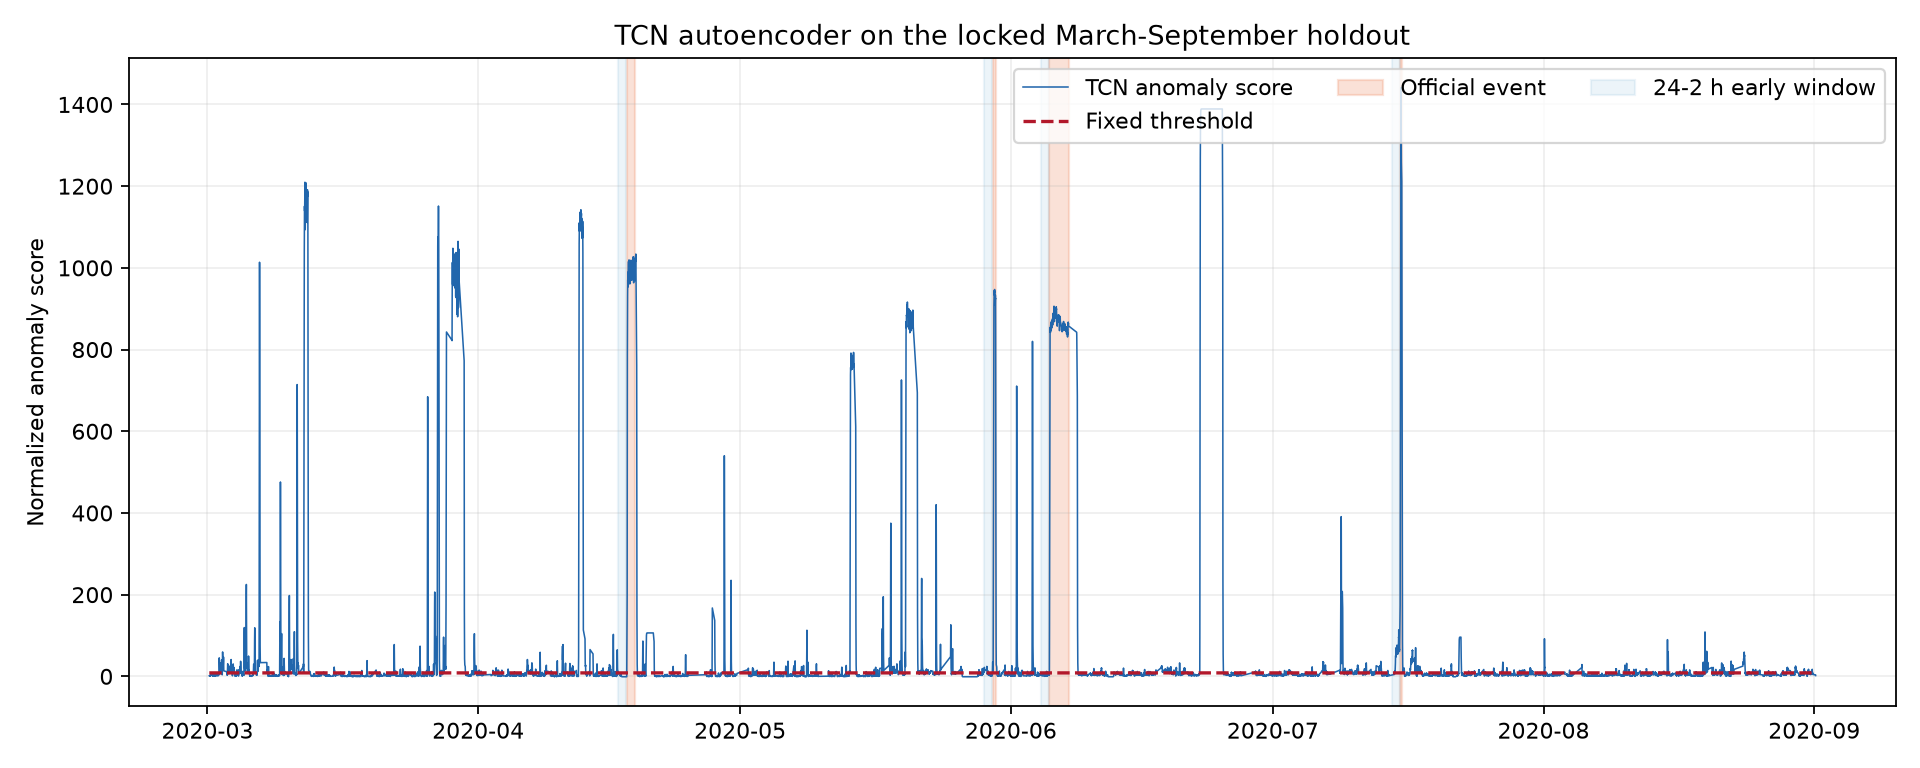

In [27]:
# Holdout zaman çizelgesinin dosya yolunu oluşturuyoruz.
timeline_png = ROOT / "reports/figures/holdout_timeline.png"

# Geniş zaman ekseninin okunabilmesi için görseli geniş gösteriyoruz.
display(Image(filename=str(timeline_png), width=1200))

## 14. TCN sinyal katkıları: reconstruction hatası hangi sensörlerde yoğunlaşıyor?

Autoencoder her sensör grubundaki yeniden oluşturma hatasını toplam skora katkı olarak raporlar.
Katkılar toplamı yaklaşık 1’dir. Bu dağılım, **modelin anomali skorunu nasıl oluşturduğunu** açıklar;
fiziksel nedensellik veya arızalı parça teşhisi değildir.

Katkı toplamı: %100.00


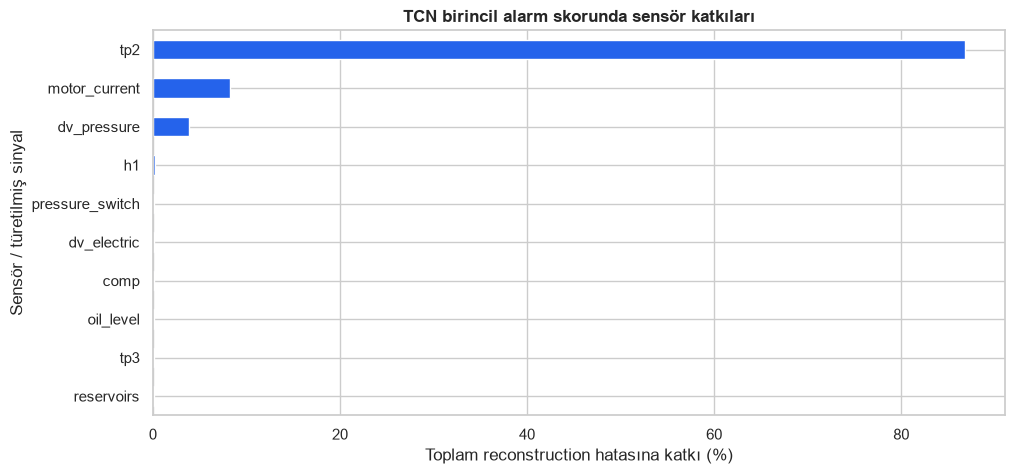

,katkı_yüzde
tp2,86.7921
motor_current,8.2946
dv_pressure,3.8267
h1,0.1935
pressure_switch,0.1694
dv_electric,0.1174
comp,0.1020
oil_level,0.0803
tp3,0.0756
reservoirs,0.0700


In [28]:
# JSON içindeki sensör katkı sözlüğünü iki sütunlu tabloya dönüştürüyoruz.
tcn_contrib = pd.Series(
    metrics_payload["primary_alert_sensor_contributions"],
    name="katkı",
).sort_values(ascending=False)

# Oranı yüzdeye çevirerek daha kolay okunmasını sağlıyoruz.
tcn_contrib_pct = (100 * tcn_contrib).rename("katkı_yüzde")

# Toplam katkının yaklaşık %100 olduğunu sayısal olarak kontrol ediyoruz.
print(f"Katkı toplamı: %{tcn_contrib_pct.sum():.2f}")

# En yüksek on sensör grubunu yatay çubuk grafikle gösteriyoruz.
ax = tcn_contrib_pct.head(10).sort_values().plot(kind="barh", color="#2563eb")
ax.set_title("TCN birincil alarm skorunda sensör katkıları")
ax.set_xlabel("Toplam reconstruction hatasına katkı (%)")
ax.set_ylabel("Sensör / türetilmiş sinyal")
plt.show()

display(tcn_contrib_pct.head(10).to_frame())

**Yorum:** `tp2` katkısının yaklaşık `%86,8` olması model hatasının bu sinyalde yoğunlaştığını
gösterir. Bu, “TP2 kesin kök nedendir” cümlesini desteklemez. TP2 başka bir fiziksel sürecin
sonucu olarak da sapmış olabilir; bakım kaydı ve mekanik doğrulama olmadan nedensellik kurulamaz.

## 15. Isolation Forest TreeSHAP açıklaması

TreeSHAP, ağaç modelinin skorunu özellik katkılarına ayırır. `mean_absolute_shap` işaret yönünü
değil, ortalama katkı büyüklüğünü ölçer. Normalize katkıların toplamı yaklaşık 1 olmalıdır.

In [29]:
# TreeSHAP özet tablosunu okuyoruz.
shap_table = pd.read_csv(files["shap"])

# En yüksek katkıdan en düşüğe sıralıyoruz.
shap_table = shap_table.sort_values("normalized_contribution", ascending=False)

# İlk on sinyali gösteriyoruz; uzun kuyruk tablonun devamında tutulur.
display(shap_table.head(10))

# Normalize katkıların beklenen toplamını kontrol ediyoruz.
print(f"Normalize SHAP katkısı toplamı: {shap_table['normalized_contribution'].sum():.6f}")

,sensor,mean_absolute_shap,normalized_contribution
0,oil_temperature,0.0663,0.1479
1,tp2,0.0503,0.1122
2,motor_current,0.0414,0.0924
3,h1,0.0397,0.0886
4,tp3,0.0319,0.0713
5,dv_electric,0.0302,0.0674
6,reservoirs,0.0298,0.0665
7,dv_pressure,0.0295,0.0659
8,comp,0.0292,0.0652
9,mpg,0.0291,0.0648


Normalize SHAP katkısı toplamı: 1.000000


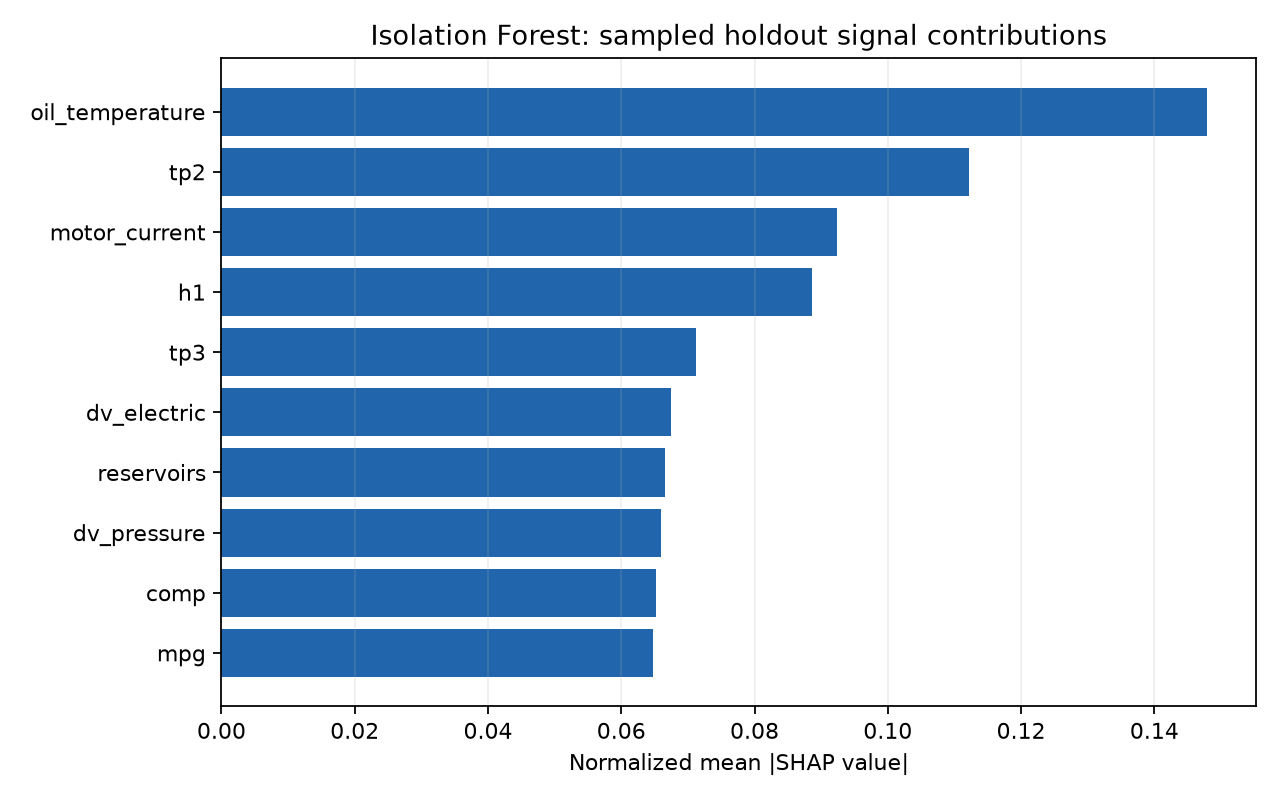

In [30]:
# Proje pipeline'ının ürettiği orijinal TreeSHAP görselini açıyoruz.
shap_png = ROOT / "reports/figures/isolation_forest_shap.png"

# Görseli notebook içine gömüyoruz.
display(Image(filename=str(shap_png), width=1000))

## 16. Leave-one-event-block-out eşik duyarlılığı

`cross_event_analysis.csv`, bir olay bloğu dışarıda bırakılıp diğer üç blok üzerinde eşik seçilen
**keşifsel** bir analizdir. Ana kilitli test sonucu değildir. Amaç, eşik seçiminin az sayıdaki olaya
ne kadar duyarlı olabileceğini görmek ve aşırı güveni azaltmaktır.

In [31]:
# Keşifsel çapraz-olay sonuçlarını okuyoruz.
cross_event = pd.read_csv(files["cross_event"])

# Model bazında seçilen eşik ve yanlış alarm dağılımını özetliyoruz.
cross_summary = cross_event.groupby("model").agg(
    eşik_min=("selected_threshold", "min"),
    eşik_max=("selected_threshold", "max"),
    ort_yanlış_alarm_gün=("false_alarms_per_day", "mean"),
    erken_blok_sayısı=("early_detected", "sum"),
)

# Sonuçların yalnız keşifsel olduğunu tablo başlığıyla birlikte gösteriyoruz.
display(cross_summary)

,eşik_min,eşik_max,ort_yanlış_alarm_gün,erken_blok_sayısı
model,,,,
isolation_forest,11.0432,11.0869,0.0000,0
pca,186.7697,194.2682,0.0101,0
robust_z,16.1878,18.2113,0.0639,0
tcn_autoencoder,"1,218.3663","1,389.1370",0.0101,0


## 17. Küçük demo replay üzerinde veri kalitesi EDA’sı

Ham 208 MB veri Git deposunda tutulmaz; ancak lisanslı küçük `replay.csv` örneği şema, zaman
aralığı ve sensör davranışını öğretmek için yeterlidir. Bu örnekten hesaplanan dağılımlar bütün
1,52 milyon satırlık veri için genellenmemelidir.

In [32]:
# Küçük tarihsel örneği okuyoruz.
demo = pd.read_csv(files["demo"])

# İlk sütunun zaman damgası adını veri sözleşmesine bağlı kalmadan algılıyoruz.
timestamp_column = "timestamp" if "timestamp" in demo.columns else demo.columns[0]

# Zaman damgasını datetime türüne çeviriyoruz; hatalı değer varsa NaT olarak görünür.
demo[timestamp_column] = pd.to_datetime(demo[timestamp_column], errors="coerce")

# Boyut, zaman aralığı ve eksik zaman bilgisiyle temel veri kalite özetini yazdırıyoruz.
print(f"Demo boyutu: {demo.shape[0]:,} satır × {demo.shape[1]:,} sütun")
print(f"Başlangıç: {demo[timestamp_column].min()}")
print(f"Bitiş:     {demo[timestamp_column].max()}")
print(f"Geçersiz zaman damgası: {demo[timestamp_column].isna().sum()}")

# İlk beş satırı göstererek şemayı somutlaştırıyoruz.
display(demo.head())

Demo boyutu: 7,220 satır × 16 sütun
Başlangıç: 2020-05-29 12:00:02
Bitiş:     2020-05-30 07:52:44
Geçersiz zaman damgası: 0


,timestamp,tp2,tp3,h1,dv_pressure,reservoirs,oil_temperature,motor_current,comp,dv_electric,towers,mpg,lps,pressure_switch,oil_level,caudal_impulses
0,2020-05-29 12:00:02,-0.0080,9.8000,9.7860,-0.0160,9.8000,71.7000,3.6875,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
1,2020-05-29 12:00:12,-0.0100,9.7780,9.7660,-0.0160,9.7800,71.7250,3.7000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
2,2020-05-29 12:00:22,-0.0100,9.7600,9.7460,-0.0160,9.7620,71.6250,3.7150,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
3,2020-05-29 12:00:32,-0.0100,9.7340,9.7200,-0.0160,9.7340,71.5250,3.7450,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
4,2020-05-29 12:00:41,-0.0100,9.7000,9.6860,-0.0160,9.7020,71.1500,3.7700,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000


,saniye
count,"7,219.0000"
mean,9.9130
std,0.2833
min,9.0000
50%,10.0000
90%,10.0000
95%,10.0000
99%,10.0000
max,12.0000


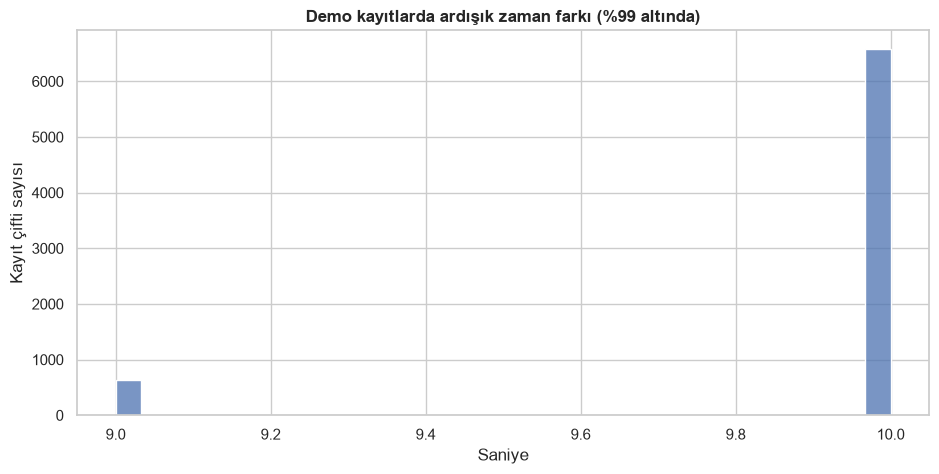

In [33]:
# Ardışık kayıtlar arasındaki saniye farkını hesaplıyoruz.
cadence_seconds = demo[timestamp_column].sort_values().diff().dt.total_seconds().dropna()

# Ortalama yerine medyanı öne çıkarıyoruz; uzun boşluklar ortalamayı kolayca yukarı çeker.
cadence_summary = cadence_seconds.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
display(cadence_summary.to_frame("saniye"))

# Uzun kuyruk nedeniyle grafiği %99 yüzdelikte kırparak olağan ritmi görünür kılıyoruz.
upper = cadence_seconds.quantile(0.99)
sns.histplot(cadence_seconds[cadence_seconds <= upper], bins=30)
plt.title("Demo kayıtlarda ardışık zaman farkı (%99 altında)")
plt.xlabel("Saniye")
plt.ylabel("Kayıt çifti sayısı")
plt.show()

**Neden medyan?** Sensör akışında tipik ritim yaklaşık 10 saniyedir; ancak bakım, bağlantı veya
veri toplama kesintileri uzun boşluklar oluşturabilir. Ortalama bu boşluklardan fazla etkilenir.
Pipeline bu nedenle kusursuz 10 saniyelik saat varsaymak yerine 5 dakikalık kutularda kapsama
kontrolü yapar ve yetersiz kutuları reddeder.

In [34]:
# Yalnızca sayısal sensör sütunlarını seçiyoruz; zaman damgası özet istatistiğe dahil edilmez.
numeric_demo = demo.select_dtypes(include="number")

# Her sensör için eksiklik, ortalama, standart sapma, medyan ve uç yüzdelikleri hesaplıyoruz.
sensor_summary = pd.DataFrame({
    "eksik_yüzde": 100 * numeric_demo.isna().mean(),
    "ortalama": numeric_demo.mean(),
    "std": numeric_demo.std(),
    "medyan": numeric_demo.median(),
    "p01": numeric_demo.quantile(0.01),
    "p99": numeric_demo.quantile(0.99),
})

# En değişken sensörleri önce göstermek için standart sapmaya göre sıralıyoruz.
display(sensor_summary.sort_values("std", ascending=False))

,eksik_yüzde,ortalama,std,medyan,p01,p99
oil_temperature,0.0000,69.0792,5.7417,68.7500,58.2500,76.4702
h1,0.0000,5.2756,4.4575,8.3420,-0.0200,10.0660
tp2,0.0000,3.4593,4.1846,-0.0100,-0.0216,10.2756
motor_current,0.0000,3.1592,2.4973,3.7712,0.0375,6.1295
dv_pressure,0.0000,0.6477,0.9410,-0.0160,-0.0220,2.1100
tp3,0.0000,8.8153,0.5582,8.5640,8.0780,10.0976
reservoirs,0.0000,8.8163,0.5572,8.5640,8.0800,10.0960
comp,0.0000,0.5863,0.4925,1.0000,0.0000,1.0000
dv_electric,0.0000,0.4137,0.4925,0.0000,0.0000,1.0000
mpg,0.0000,0.5863,0.4925,1.0000,0.0000,1.0000


## 18. Ne söylenebilir, ne söylenemez?

**Desteklenen ifadeler**

- Kilitli Mart–Eylül testinde TCN dört olayın üçünü 24–2 saat erken pencerede işaretledi.
- Isolation Forest daha yüksek PR-AUC üretti fakat test zamanının daha büyük bölümünde alarmdaydı.
- TCN alarm reconstruction katkısında TP2 baskındı.

**Desteklenmeyen ifadeler**

- “Model %75 doğrulukla arıza tahmin ediyor.” (`3/4`, güvenilir genel doğruluk oranı değildir.)
- “TP2 arızanın kök nedenidir.” (Katkı nedensellik değildir.)
- “Model başka trenlerde de aynı performansı verir.” (Tek APU incelendi.)
- “Şubat tamamen sağlıklıydı.” (Yalnız raporlanmış arıza yoktu.)

## 19. Sonuç özeti

MetroGuard’ın ana dersi, yüksek yakalamanın tek başına yeterli olmadığıdır. İyi bir erken uyarı
sistemi üç şeyi birlikte yönetir:

1. **Olay yakalama:** kaç olay gerçekten erken işaretlendi?
2. **Alarm bütçesi:** ekip ne kadar süre alarm görür ve günde kaç gereksiz epizot oluşur?
3. **Açıklanabilirlik:** skoru hangi sinyaller sürüklüyor ve bu açıklamanın sınırı nedir?

Birincil TCN `3/4` erken olay, `15,6 saat` medyan lead time ve `1,259` yanlış alarm/gün üretir.
Isolation Forest karşılaştırması daha yüksek PR-AUC ve `4/4` erken yakalama sunarken `%35,36`
alarm süresiyle daha ağır bir operasyonel yük taşır. Bu nedenle sonuç “tek kazanan model” yerine
şeffaf bir ödünleşim olarak raporlanmalıdır.